In [1]:
from IPython.display import Image, display, SVG, HTML

from typing import Dict, List, Tuple, Callable, Any
from numpy.linalg import lstsq
# from interval_timeline import CallGraph
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import re
from scipy import stats

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import otf2
import hatchet as ht
import thicket as tt

In [2]:
TRACES = [
    # 'scorep-traces/scorep-more-metrics/traces.otf2',
    # 'scorep-traces/idle-compute-step-8-freq-and-capped/idle-compute-step-600ms-600ms/traces.otf2'
    # "./scorep-traces/rocHPL-verify-craypm-freshness-counter-4/traces.otf2"
    # "./scorep-traces/rocHPL-verify-craypm-freshness-counter-4/traces.otf2"
    "/Users/adam/Documents/ornl/internship-2025/hpc-energy-trace-analysis/frontier-results/step_function-r4---vector_size_134217728_--n_steps_7_--time_active_1000_--time_sleep_1000/trial_1-frontier09470-r4-step_function---vector_size_134217728_--n_steps_7_--time_active_1000_--time_sleep_1000/traces.otf2"
]

In [3]:
# TRACE_DIR = "./scorep-traces/mi300-multiple-kernels-two-gpus/traces.otf2"
PROCESSES_TO_TRACK = [
    'MPI Rank 0',
    # 'Process',
]
METRICS_TO_TRACK = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::temp_current:device=0:sensor=0',
    'A2rocm_smi:::busy_percent:device=0',
    'A2rocm_smi:::memory_busy_percent:device=0',
    
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',
    
    'A2coretemp:::craypm:power',
    'A2coretemp:::craypm:freshness',
    
    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
    
    'A3coretemp:::craypm:accel0_energy',
    'A3coretemp:::craypm:accel1_energy',
    'A3coretemp:::craypm:accel2_energy',
    'A3coretemp:::craypm:accel3_energy',
    
    'A2coretemp:::craypm:accel0_power',
    'A2coretemp:::craypm:accel1_power',
    'A2coretemp:::craypm:accel2_power',
    'A2coretemp:::craypm:accel3_power',

    'A3coretemp:::craypm:accel0_power',
    'A3coretemp:::craypm:accel1_power',
    'A3coretemp:::craypm:accel2_power',
    'A3coretemp:::craypm:accel3_power',
]

def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    df = pd.read_csv(file)
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name:
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    return pd.read_csv(file)


In [4]:
# Remove all the old CSV files
for file in os.listdir('.'):
    if file.endswith('.csv'):
        os.remove(file)

In [5]:
def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str], cray_time_offset=0.0):
    # Remove all the old CSV files
    for file in os.listdir('.'):
        if file.endswith('.csv'):
            os.remove(file)
    print(f'Tracking metrics: {metrics_to_track}')
    # Shell out to ./trace_to_csv_parallel binary with `./trace_to_csv_parallel --tracePath=/path/to/trace.otf2`
    cmd = f'./trace_to_csv_parallel --trace={trace} --metrics="{",".join(metrics_to_track)}"'
    print(f"Running command: {cmd}")
    os.system(cmd)
    
# Visualize the dataframes
def visualize_dataframe(df):
    """Visualize the first few rows of a DataFrame as HTML."""
    # pd.set_option("display.width", 2400)
    # pd.set_option("display.max_colwidth", 100)
    # pd.set_option("display.max_rows", 20)
    
    display(HTML(df.head(n=20).to_html(index=False)))

# trace_to_csv(TRACE_DIR, PROCESSES_TO_TRACK, METRICS_TO_TRACK)
# visualize_dataframe(read_metrics_dataframe(f"{PROCESSES_TO_TRACK[0]}_metrics.csv"))
# visualize_dataframe(read_call_graph_dataframe(f"{PROCESSES_TO_TRACK[0]}_Master_thread_callgraph.csv"))

In [6]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    # Apply a savgol filter to smooth the data
    # y = scipy.signal.savgol_filter(y, window_length=11, polyorder=2, mode='nearest')
    # Apply a median filter to smooth the data
    # y = scipy.signal.medfilt(y, kernel_size=11)
 
    # Create a continuous function that interpolates the sampled data
    f = lambda t: np.interp(t, t_samples, y)
    return f

def windowed_average(f, window_period=0.1, sample_period=0.001):
    """
    Return a function F(x) that computes the average of f(t) over a window of size window_size.
    The function F(x) will return a scalar when x is a scalar, and an array when x is an array.
    """
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Create a time grid for the window
        t_grid = np.arange(-window_period / 2, window_period / 2, sample_period)
        # Compute the average over the window
        avg = np.array([np.mean(f(t + t_grid)) for t in x_arr])
        return avg.item() if np.isscalar(x) else avg
    
    return F

def windowed_median(f, window_period=0.1, sample_period=0.001):
    """
    Return a function F(x) that computes the median of f(t) over a window of size window_size.
    The function F(x) will return a scalar when x is a scalar, and an array when x is an array.
    """
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Create a time grid for the window
        t_grid = np.arange(-window_period / 2, window_period / 2, sample_period)
        # Compute the median over the window
        med = np.array([np.median(f(t + t_grid)) for t in x_arr])
        return med.item() if np.isscalar(x) else med
    
    return F

def windowed_savgol(f, sample_period=0.1, polyorder=2):
    """
    Return a function F(x) that applies a Savitzky-Golay filter to f(t) over a window of size window_size.
    The function F(x) will return a scalar when x is a scalar, and an array when x is an array.
    """
    return lambda x: scipy.signal.savgol_filter(
        np.array([f(t) for t in np.atleast_1d(x).astype(float)]),
        window_length=ceil(1/sample_period),  # Convert window size to number of samples
        polyorder=polyorder,
        mode='nearest'
    )

def numerical_derivative(func, h=1e-3):
    """Compute the numerical derivative of a function at a point t."""
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    """
    Return a function F(x) that approximates the integral of f(t) dt from t=a to t=x,
    using the trapezoidal rule in a fully vectorized manner.
    The function F(x) will return a scalar when x is a scalar, and an array
    when x is an array.
    """
    # Determinar si f soporta arrays de NumPy
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Manejo de x < a invirtiendo signo
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        # Grid hasta el máximo de x
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        # Suma acumulada de trapecios
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        # Índices y remanentes
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        # Valores en fronteras
        f_end = f_np(x_pos)
        f_start = u[idx]
        
        # Integral aproximada
        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        # Devolver escalares cuando corresponda
        return result.item() if np.isscalar(x) else result
    
    return F
        

def create_hatchet_dag(call_graph_df, metrics_df):
    # Add a column for the inclusive energy of each call in the call graph
    call_graph_df = call_graph_df.copy()
        
    # Now create a map of continuous functions for each device
    energy_accumulated = {
        metric_name: sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == metric_name]) if 'energy' in metric_name
        else numerical_integral(sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == metric_name]))
        for metric_name in metrics_df['Metric Name'].unique()
    }

    # Sort the call graph by their start time
    call_graph_df = call_graph_df.sort_values(by='Start Time')
    # 1) Generar lista de eventos
    events = []
    print("Creating events from call graph...")
    for _idx, row in call_graph_df.iterrows():
        duration = row['Duration']
        events.append({
            'type': 'enter',
            'time': row['Start Time'],
            'name': row['Name'],
            'duration': duration,
            'metrics': {metric: energy_accumulated[metric](row['End Time']) - energy_accumulated[metric](row['Start Time'])
              for metric in energy_accumulated.keys()}
        })
        events.append({
            'type': 'exit',
            'time': row['End Time'],
            'name': row['Name'],
            'duration': duration
        })
    print(f"Total events created: {len(events)}")
    
    # 2) Ordenar por tiempo, con 'enter' antes que 'exit' en igualdad
    events.sort(key=lambda e: (e['time'], 0 if e['type']=='enter' else 1))

    # 3) Recorrer eventos y construir DAG
    dag = []
    stack = []
    print("Building DAG from events...")
    for ev in events:
        if ev['type'] == 'enter':
            node = {
                'frame': {'name': ev['name']},
                'metrics': {
                    'time (inc)': ev['duration'],
                    'time': 0.0,  # se calculará al hacer el 'exit'
                } | ev['metrics'],
                'children': []
            }
            if stack:
                stack[-1]['children'].append(node)
            else:
                dag.append(node)
            stack.append(node)

        else:  # ev['type'] == 'exit'
            node = stack.pop()
            # sumar duraciones inclusivas de los hijos
            child_incs = sum(ch['metrics']['time (inc)'] for ch in node['children'])
            # tiempo exclusivo = inclusivo - suma de hijos
            node['metrics']['time'] = node['metrics']['time (inc)'] - child_incs

    print(f"DAG created with {len(dag)} root nodes.")
    return dag

def create_hatchet_graph(call_graph_df, metrics_df):
    print("Creating Hatchet DAG from call graph...")
    dag = create_hatchet_dag(call_graph_df, metrics_df)
    print("DAG created successfully.")
    gf = ht.GraphFrame.from_literal(dag)
    print("GraphFrame created from DAG.")
    # print("Creating Thicket from DAG...")
    # tf = tt.Thicket.from_literal(dag)
    # print("Thicket created from DAG.")
    # tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
    return gf

def create_thicket_graph(call_graph_df, metrics_df):
    """Create a Thicket graph from the call graph and metrics DataFrame."""
    print("Creating Hatchet DAG from call graph...")
    dag = create_hatchet_dag(call_graph_df, metrics_df)
    print("DAG created successfully.")
    gf = ht.GraphFrame.from_literal(dag)
    print("GraphFrame created from DAG.")
    
    # Create a Thicket from the DAG
    tf = tt.Thicket.from_literal(dag)
    print("Thicket created from DAG.")
    tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
    
    return gf, tf

def create_hatchet_and_thicket_graphs(call_graph_df, metrics_df):
    """Create a Thicket graph from the call graph and metrics DataFrame."""
    print("Creating Hatchet DAG from call graph...")
    dag = create_hatchet_dag(call_graph_df, metrics_df)
    print("DAG created successfully.")
    gf = ht.GraphFrame.from_literal(dag)
    print("GraphFrame created from DAG.")
    
    # Create a Thicket from the DAG
    tf = tt.Thicket.from_literal(dag)
    print("Thicket created from DAG.")
    tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
    return gf, tf

In [7]:
def load_trace(trace_path: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load the trace for a specific idle and active period."""
    try:
        # trace_path = get_run_trace_path(idle_period_ms, active_period_ms)
        if not os.path.exists(trace_path):
            raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
        # print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
        trace_to_csv(trace_path, PROCESSES_TO_TRACK, METRICS_TO_TRACK)
        # Load the CSV files into dataframes
        metrics_df = read_metrics_dataframe(f"{PROCESSES_TO_TRACK[0]}_metrics.csv")
        call_graph_df = read_call_graph_dataframe(f"{PROCESSES_TO_TRACK[0]}_Master_thread_callgraph.csv")
    except Exception as e:
        print(f"Error loading trace: {e}")
        metrics_df = pd.DataFrame(columns=['Group', 'Metric Name', 'Time', 'Value'])
        call_graph_df = pd.DataFrame(columns=['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'])
    return metrics_df, call_graph_df

traces = {
    trace: load_trace(trace)
    for trace in TRACES
}

Tracking metrics: ['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::temp_current:device=0:sensor=0', 'A2rocm_smi:::busy_percent:device=0', 'A2rocm_smi:::memory_busy_percent:device=0', 'A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6', 'A2coretemp:::craypm:power', 'A2coretemp:::craypm:freshness', 'A2coretemp:::craypm:accel0_energy', 'A2coretemp:::craypm:accel1_energy', 'A2coretemp:::craypm:accel2_energy', 'A2coretemp:::craypm:accel3_energy', 'A3coretemp:::craypm:accel0_energy', 'A3coretemp:::craypm:accel1_energy', 'A3coretemp:::craypm:accel2_energy', 'A3coretemp:::craypm:accel3_energy', 'A2coretemp:::craypm:accel0_power', 'A2coretemp:::craypm:accel1_power', 'A2coretemp:::craypm:accel2_power', 'A2coretemp:::craypm:accel3_power', 'A3coretemp:::craypm:accel0_power', 'A3coretemp:::craypm:accel1_power', 'A3coretemp:::craypm:accel2_power', 'A3coretemp:::craypm:accel3_power']
Running command

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_79059/3252290304.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.90010198e+09 1.90010198e+09 1.90010198e+09 ... 1.90010524e+09
 1.90010524e+09 1.90010524e+09]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


In [8]:
TRACE = list(traces.keys())[0]

In [9]:
def find_time_offset(f1, f2, t_min=0.0, t_max=100.0):
    '''
    Sync up the two functions by sliding f2 over f1 and finding the offset that maximizes
    the correlation between them.
    
    This function returns an offset that should be added to the input to f2 to align it with f1.
    '''
    t_common = np.linspace(t_min, t_max, num=10000)
    print(f"Correlation before sync: {np.corrcoef(f1(t_common), f2(t_common))[0, 1]}")
    # Slide f2 over f1 to find
    best_offset = 0.0
    best_corr = -1.0
    for offset in np.linspace(-1.0, 1.0, num=10000):
        y1 = f1(t_common)
        y2 = f2(t_common + offset)
        corr = np.corrcoef(y1, y2)[0, 1]
        if corr > best_corr:
            best_corr = corr
            best_offset = offset
    print(f"Best offset: {best_offset} seconds (corr={best_corr})")
    return best_offset
    
# Find the X-axis offset to align the metrics for Cray and ROCm
def find_time_offset_dataframe(metrics_df, metric_name_1, metric_name_2):
    df1 = metrics_df[metrics_df['Metric Name'] == metric_name_1]
    df2 = metrics_df[metrics_df['Metric Name'] == metric_name_2]
    f1 = sampled_to_continuous(df1)
    f2 = sampled_to_continuous(df2)
    
    t1 = df1['Time'].astype(float)
    t2 = df2['Time'].astype(float)
    t_min = max(t1.min(), t2.min())
    t_max = min(t1.max(), t2.max())
    best_offset = find_time_offset(f1, f2, t_min, t_max)
    return best_offset

In [10]:
print("Finding time offset between Cray and ROCm metrics...")
time_offset = find_time_offset_dataframe(
    traces[TRACE][0],
    'A2rocm_smi:::energy_count:device=0',
    'A2coretemp:::craypm:accel0_energy',
)
print(f"Time offset found: {time_offset} seconds")

Finding time offset between Cray and ROCm metrics...
Correlation before sync: 0.9998484554289894
Best offset: 0.07790779077907795 seconds (corr=0.9998969449402394)
Time offset found: 0.07790779077907795 seconds


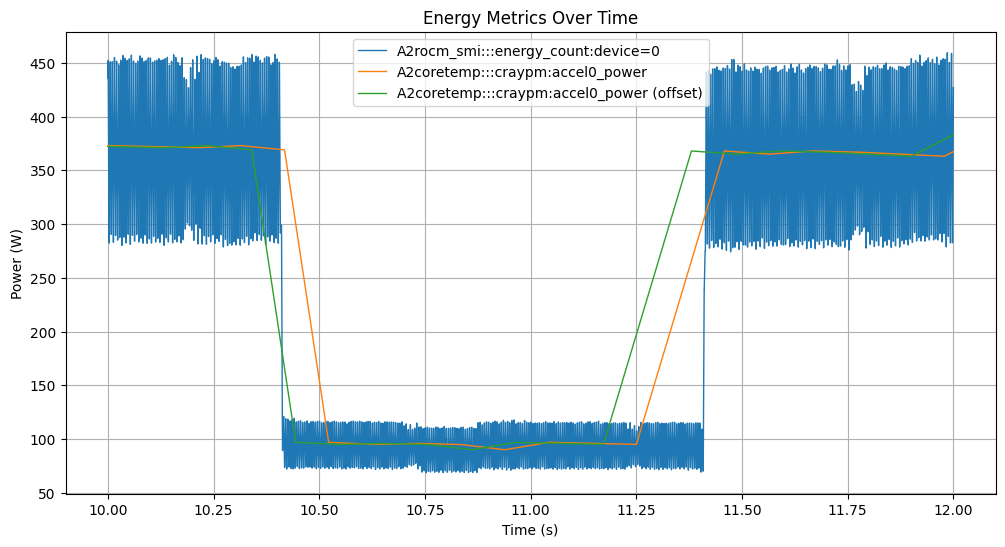

In [11]:
# Graph the rocm, cray, and cray offset by the time offset
def plot_metrics(metrics_df, time_offset: float):
    plt.figure(figsize=(12, 6))
    # Plot the first rocm energy metric
    rocm_metric = 'A2rocm_smi:::energy_count:device=0'
    cray_metric = 'A2coretemp:::craypm:accel0_power'
    df_rocm = numerical_derivative(sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == rocm_metric]))
    df_cray = sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == cray_metric])
    df_cray_offset = lambda t: sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == cray_metric])(t + time_offset)
    
    x = np.linspace(10, 12, num=20000)
    y_rocm = df_rocm(x)
    y_cray = df_cray(x)
    y_cray_offset = df_cray_offset(x)
    plt.plot(x, y_rocm, label=rocm_metric, lw=1)
    plt.plot(x, y_cray, label=cray_metric, lw=1)
    plt.plot(x, y_cray_offset, label=f"{cray_metric} (offset)", lw=1)
    # plt.plot(df_rocm['Time'], df_rocm['Value'] - df_rocm['Value'].min(), label=rocm_metric)
    # plt.plot(df_cray['Time'], df_cray['Value'] - df_cray['Value'].min(), label=cray_metric)
    # plt.plot(df_cray_offset['Time'], df_cray_offset['Value'] - df_cray_offset['Value'].min(), label=f"{cray_metric} (offset)")
    plt.xlabel('Time (s)')
    plt.ylabel('Power (W)')
    plt.title('Energy Metrics Over Time')
    plt.legend()
    plt.grid()
    plt.show()
plot_metrics(traces[TRACE][0], time_offset)

In [12]:
# Create a map of GPU energy functions for each trace
gpu_energy_functions = {
    trace: {
        f'{name} (energy)': sampled_to_continuous(df[df['Metric Name'] == name]) if 'energy' in name
        else numerical_integral(sampled_to_continuous(df[df['Metric Name'] == name]))
        for name in df['Metric Name'].unique() 
    } for trace, (df, _) in traces.items()
}
print(gpu_energy_functions)


{'/Users/adam/Documents/ornl/internship-2025/hpc-energy-trace-analysis/frontier-results/step_function-r4---vector_size_134217728_--n_steps_7_--time_active_1000_--time_sleep_1000/trial_1-frontier09470-r4-step_function---vector_size_134217728_--n_steps_7_--time_active_1000_--time_sleep_1000/traces.otf2': {'A2rocm_smi:::energy_count:device=6 (energy)': <function sampled_to_continuous.<locals>.<lambda> at 0x11e6eefc0>, 'A2rocm_smi:::busy_percent:device=0 (energy)': <function numerical_integral.<locals>.F at 0x11f29ba60>, 'A2rocm_smi:::energy_count:device=4 (energy)': <function sampled_to_continuous.<locals>.<lambda> at 0x11f29bb00>, 'A2rocm_smi:::energy_count:device=2 (energy)': <function sampled_to_continuous.<locals>.<lambda> at 0x11f29bba0>, 'A2rocm_smi:::energy_count:device=0 (energy)': <function sampled_to_continuous.<locals>.<lambda> at 0x11f29bc40>, 'A2coretemp:::craypm:power (energy)': <function numerical_integral.<locals>.F at 0x11f29bd80>, 'A2coretemp:::craypm:accel1_power (energ

In [13]:

# Create a map of gpu power functions for each trace
gpu_power_functions = {
    trace: {
        f'{name} (power)': sampled_to_continuous(df[df['Metric Name'] == name]) if 'power' in name
        else numerical_derivative(sampled_to_continuous(df[df['Metric Name'] == name]))
        for name in df['Metric Name'].unique() 
    } for trace, (df, _) in traces.items()
}
print(gpu_power_functions)

{'/Users/adam/Documents/ornl/internship-2025/hpc-energy-trace-analysis/frontier-results/step_function-r4---vector_size_134217728_--n_steps_7_--time_active_1000_--time_sleep_1000/trial_1-frontier09470-r4-step_function---vector_size_134217728_--n_steps_7_--time_active_1000_--time_sleep_1000/traces.otf2': {'A2rocm_smi:::energy_count:device=6 (power)': <function numerical_derivative.<locals>.<lambda> at 0x11f1fa200>, 'A2rocm_smi:::busy_percent:device=0 (power)': <function numerical_derivative.<locals>.<lambda> at 0x11f2b0a40>, 'A2rocm_smi:::energy_count:device=4 (power)': <function numerical_derivative.<locals>.<lambda> at 0x11f2b0b80>, 'A2rocm_smi:::energy_count:device=2 (power)': <function numerical_derivative.<locals>.<lambda> at 0x11f2b0cc0>, 'A2rocm_smi:::energy_count:device=0 (power)': <function numerical_derivative.<locals>.<lambda> at 0x11f2b0e00>, 'A2coretemp:::craypm:power (power)': <function sampled_to_continuous.<locals>.<lambda> at 0x11f2b0ea0>, 'A2coretemp:::craypm:accel1_pow

Correlation before sync: -0.031373459183270364
Best offset: -0.9921992199219922 seconds (corr=0.10918033872408645)
Correlation before sync: 0.8954085236909874
Best offset: 0.06910691069106911 seconds (corr=0.9225965306052651)
Correlation before sync: -0.025458012242758787
Best offset: -0.9921992199219922 seconds (corr=0.08673331480690426)


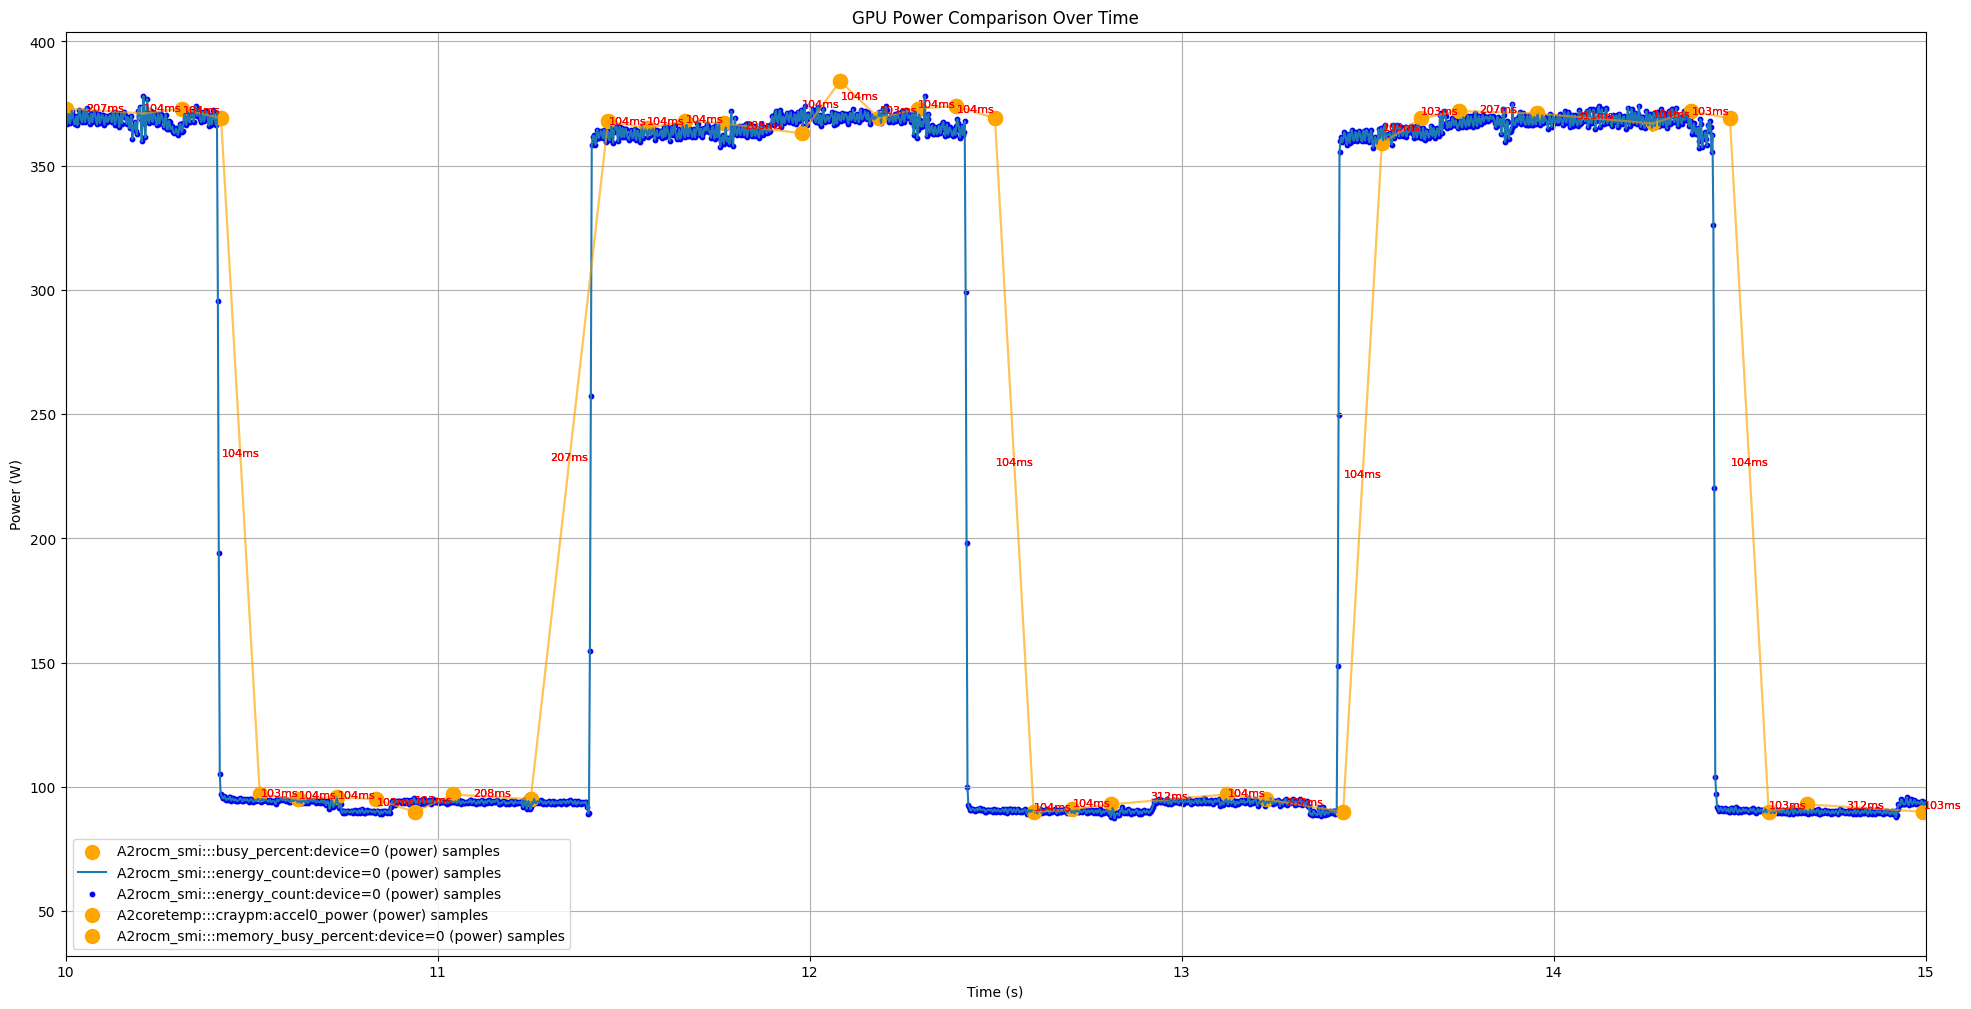

In [14]:
# Now, graph the first second of power for each trace on the same graph
def plot_power_comparison(trace_powers, trace_samples, time_offset: float, t_min=10.0, t_max=20):
    plt.figure(figsize=(24, 12))
    x = np.linspace(t_min, t_max, num=int((t_max - t_min) * 10000))
    # Use rocm0 as a reference
    ref_line = trace_powers.get('A2rocm_smi:::energy_count:device=0 (power)', None)
    # Now, line up the other lines to match the reference line
    
    # Set x range
    plt.xlim(t_min, t_max)
    for name, power in trace_powers.items():
        # if '0' not in name: continue
        if name == 'A2rocm_smi:::energy_count:device=0 (power)':
            y = power(x)
            samples = trace_samples[trace_samples['Metric Name'] == 'A2rocm_smi:::energy_count:device=0']
            plt.plot(samples['Time'], trace_powers['A2rocm_smi:::energy_count:device=0 (power)'](samples['Time']), label=f"{name} samples")
            plt.scatter(samples['Time'], trace_powers['A2rocm_smi:::energy_count:device=0 (power)'](samples['Time']), label=f"{name} samples", s=10, color='blue')
            # plt.plot(x, y, label=name, lw=1)
            # print(trace_samples)
            # Do a scatter plot of all the trace samples
            # samples = trace_samples[trace_samples['Metric Name'] == 'A2rocm_smi:::energy_count:device=0']
            # Plot the samples over time as a scatter plot
            # plt.scatter(samples['Time'], numerical_derivative(sampled_to_continuous(samples))(samples['Time']), label=f"{name} samples", s=10)
        else:
            if ('cray' in name and 'energy' in name) or '0' not in name: continue
            # Align this line to the reference line
            best_offset = find_time_offset(ref_line, power, t_min=10.0, t_max=20.0)
            # print(f"Aligning {name} with offset {best_offset} seconds")
            # # y = power(x + best_offset)
            # y = power(x)
            # plt.plot(x, y, label=f"{name} (offset {best_offset:.3f}s)", lw=1)
            samples = trace_samples[trace_samples['Metric Name'] == 'A2coretemp:::craypm:accel0_power']
            
            df = trace_samples[trace_samples['Metric Name'] == 'A2coretemp:::craypm:accel0_power']
            # Remove duplicate values
            # df = df.drop_duplicates(subset=['Value'])
            time_deltas = np.diff(df['Time'].astype(float))
            # Do a scatter plot of the samples, no sampling or derivative
            plt.scatter(samples['Time'], samples['Value'], label=f"{name} samples", s=100, color='orange')
            # Draw annotated lines that show the time deltas between cray samples
            for i in range(1, len(df)):
                t1 = df.iloc[i - 1]['Time']
                t2 = df.iloc[i]['Time']
                delta = t2 - t1
                if t1 < t_min or t1 > t_max: continue
                plt.plot([t1, t2], [df.iloc[i - 1]['Value'], df.iloc[i]['Value']], color='orange', alpha=0.3)
                plt.text((t1 + t2) / 2, (df.iloc[i - 1]['Value'] + df.iloc[i]['Value']) / 2, f"{int(delta*1000)}ms", color='red', fontsize=8, ha='center')
            
            # plt.scatter(samples['Time'] + best_offset, samples['Value'], label=f"{name} samples", s=100, color='red')
            # y = power(x)
            # plt.plot(x, y, label=f"{name} (offset {time_offset:.3f}s)", lw=1)
    # Plot the temp, percent busy, and memory usage for the rocm device on a twin axis
    plt.xlabel('Time (s)')
    plt.ylabel('Power (W)')
    # plt.twinx()
    # samples = trace_samples[trace_samples['Metric Name'] == 'A2rocm_smi:::temp_current:device=0:sensor=0']
    # plt.scatter(samples['Time'], samples['Value'], label='A2rocm_smi:::temp_current:device=0:sensor=0 samples', s=10, color='green')
    # samples = trace_samples[trace_samples['Metric Name'] == 'A2rocm_smi:::busy_percent:device=0']
    # plt.scatter(samples['Time'], samples['Value'], label='A2rocm_smi:::busy_percent:device=0 samples', s=10, color='purple')
    # samples = trace_samples[trace_samples['Metric Name'] == 'A2rocm_smi:::memory_busy_percent:device=0']
    # plt.scatter(samples['Time'], samples['Value'], label='A2rocm_smi:::memory_busy_percent:device=0 samples', s=10, color='pink')
    # plt.ylabel('%')
    # plt.yscale('log')
    plt.title('GPU Power Comparison Over Time')
    plt.legend()
    plt.grid()
    plt.show()
plot_power_comparison(gpu_power_functions[TRACE], traces[TRACE][0], time_offset, t_min=10, t_max=15)

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_79059/1111642573.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


<Figure size 600x600 with 0 Axes>

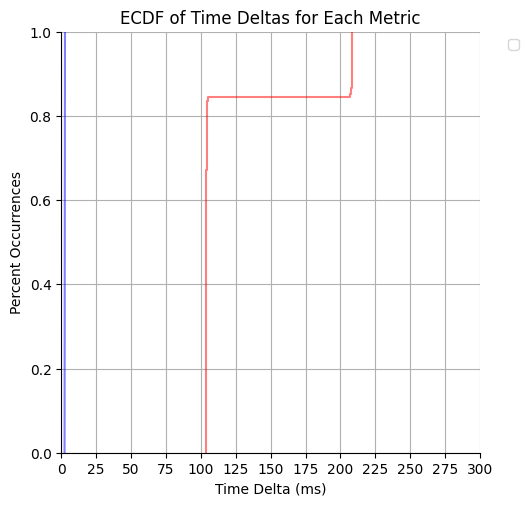

In [15]:
# # Show a histogram of all the time deltas for each metric in the metrics dataframe
# def plot_time_deltas(metrics_df):
#     plt.figure(figsize=(12, 6))
#     for metric_name in metrics_df['Metric Name'].unique():
#         if 'energy' not in metric_name:
#             continue
#         df = metrics_df[metrics_df['Metric Name'] == metric_name]
#         # Remove duplicate values
#         # df = df.drop_duplicates(subset=['Value'])
#         time_deltas = np.diff(df['Time'].astype(float))
#         # Record all the 
#         plt.hist(time_deltas, bins=50, alpha=0.9, label=metric_name, histtype='bar', log=True)
#     plt.xlabel('Time Delta (s)')
#     plt.ylabel('Occurrences')
#     plt.title('Histogram of Time Deltas for Each Metric')
#     # Use log scale for y axis
#     plt.legend()
#     plt.grid()
#     plt.show()

# Do the histogram all at once instead of multiple calls
def plot_time_deltas(metrics_df):
    plt.figure(figsize=(6, 6))
    all_time_deltas = []
    labels = []
    for metric_name in metrics_df['Metric Name'].unique():
        if 'energy' not in metric_name and 'power' not in metric_name and 'freshness' not in metric_name:
            continue
        if 'cray' in metric_name and 'freshness' not in metric_name:
            continue
        if 'rocm' in metric_name and '0' not in metric_name:
            continue
        # if 'energy' not in metric_name:
        #     continue
        df = metrics_df[metrics_df['Metric Name'] == metric_name]
        # Remove duplicate values
        # df = df.drop_duplicates(subset=['Value'])
        time_deltas = np.diff(df['Time'].astype(float))
        all_time_deltas.append(time_deltas * 1000)
        labels.append(metric_name)

    # Make each color slightly different shades
    rocm_names = [name for name in labels if 'rocm' in name]
    cray_names = [name for name in labels if 'cray' in name]

    rocm_colors = [plt.cm.winter(i / len(rocm_names)) for i in range(len(rocm_names))]
    cray_colors = [plt.cm.autumn(i / len(cray_names)) for i in range(len(cray_names))]
    colors = []
    for label in labels:
        if 'rocm' in label:
            colors.append(rocm_colors[0])
            rocm_colors = rocm_colors[1:] + [rocm_colors[0]]
        else:
            colors.append(cray_colors[0])
            cray_colors = cray_colors[1:] + [cray_colors[0]]

    # Create a swarm plot
    lengths = [len(d) for d in all_time_deltas]
    if sum(lengths) > 0:
        df_plot = pd.DataFrame({
            'Metric': np.repeat(labels, lengths),
            'Delta_ms': np.concatenate(all_time_deltas)
        })
        
        sns.displot(
            data=df_plot,
            x='Delta_ms',
            hue='Metric',
            palette=colors,
            kind="ecdf",
            alpha=0.5,
            legend=False,
        )

    # plt.hist(all_time_deltas, alpha=1.0, label=labels, histtype='bar', log=True, color=colors)
    # Use line plots
    # Plot the distribution
    # for time_deltas, label, color in zip(all_time_deltas, labels, colors):
    #     plt.plot(np.arange(len(time_deltas)), time_deltas, label=label, color=color)

    plt.xlabel('Time Delta (ms)')
    plt.ylabel('Percent Occurrences')
    plt.title('ECDF of Time Deltas for Each Metric')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 300)
    # # More xticks
    plt.xticks(np.arange(0, 301, 25))
    # Use log scale for y axis
    plt.grid()
    plt.show()

plot_time_deltas(traces[TRACE][0])

In [16]:
# # Now, create a square wave estimation of the compute activity based on the idle and active periods
# def estimate_square_wave(f: Callable[[float], float], t_min=0.0, t_max=30.0, samples_per_second=1000, max_iter=10):
#     """Estimate a square wave from a continuous function f(t) based on a threshold."""
#     t_samples = np.linspace(t_min, t_max, num=int((t_max - t_min) * samples_per_second))
#     y_samples = f(t_samples)
#     # Normalize y_samples to [0, 1]
#     # Find the average minimum
#     y_min = np.percentile(y_samples, 5)
#     y_max = np.percentile(y_samples, 95)
#     # Start with a threshold in the middle
#         # y_min = y_samples.min()
#     # y_max = y_samples.max()
#     # print(f"Using threshold {threshold} (raw value {threshold * (y_max - y_min) + y_min}) for square wave estimation")
#     # Find a threshold that minimizes the difference between the original signal and the square wave
#     threshold = y_max * 0.9
#     # falling_threshold = y_min + (y_max - y_min) * 0.1
#     # Adjust threshold to minimize error
#     best_threshold = threshold
#     best_error = float('inf')
#     for t in np.linspace(y_min, y_max, num=100):
#         y_norm = (y_samples - y_min) / (y_max - y_min)
#         square_wave = np.where(y_norm > (t - y_min) / (y_max - y_min), 1.0, 0.0)
#         error = np.mean((y_samples - (square_wave * (y_max - y_min) + y_min))**2)
#         if error < best_error:
#             best_error = error
#             best_threshold = t
#             print(f"New best threshold {best_threshold} with error {best_error} beats {threshold}")
#     # Now find the samples per second that minimizes the error
#     error = best_error
#     direction = 100
#     while True:
#         if max_iter == 0:
#             print("Max iterations reached in samples per second adjustment")
#             break
#         max_iter -= 1
        
#         # # Do a binary search to find the best samples per second
#         # # new_samples_per_second = samples_per_second + direction
#         # # Check if it improves the error
#         # t_samples = np.linspace(t_min, t_max, num=int((t_max - t_min) * samples_per_second))
#         # y_samples = f(t_samples)
#         # y_norm = (y_samples - y_min) / (y_max - y_min)
#         # square_wave = np.where(y_norm > (best_threshold - y_min) / (y_max - y_min), 1.0, 0.0)
#         # new_error = np.mean((y_samples - (square_wave * (y_max - y_min) + y_min))**2)
#         # if new_error < error:
#         #     error = new_error
#         #     # samples_per_second = new_samples_per_second
#         # else:
#         #     direction = -direction // 2
        
#         # Try increasing or decreasing the samples per second
#         new_samples_per_second = samples_per_second + direction
#         t_samples = np.linspace(t_min, t_max, num=int((t_max - t_min) * new_samples_per_second))
#         y_samples = f(t_samples)
#         y_norm = (y_samples - y_min) / (y_max - y_min)
#         square_wave = np.where(y_norm > (best_threshold - y_min) / (y_max - y_min), 1.0, 0.0)
#         new_error = np.mean((y_samples - (square_wave * (y_max - y_min) + y_min))**2)
#         if new_error < error:
#             error = new_error
#             samples_per_second = new_samples_per_second
#         else:
#             direction = -direction // 2
#     print(f"Using {samples_per_second} samples per second for square wave estimation")
#     threshold = (best_threshold - y_min) / (y_max - y_min)
#     print(f"New best threshold {threshold} with error {error}")
#     print(f"Using threshold {threshold} (raw value {threshold * (y_max - y_min) + y_min}) for square wave estimation")
    
#     y_norm = (y_samples - y_min) / (y_max - y_min)
#     # Create square wave based on threshold
#     square_wave = np.where(y_norm > threshold, 1.0, 0.0)
    
#     # Average all the values in the high state and low state
    
#     active_amplitude = y_samples[square_wave == 1].mean() if np.any(square_wave == 1) else y_max
#     idle_amplitude = y_samples[square_wave == 0].mean() if np.any(square_wave == 0) else y_min
#     print(f"Idle amplitude: {idle_amplitude}, Active amplitude: {active_amplitude}")
#     # Scale the square wave to match the idle and active amplitudes
#     square_wave = square_wave * (active_amplitude - idle_amplitude) + idle_amplitude
    
#     return lambda t: np.interp(t, t_samples, square_wave)

# # Create a map of compute activity functions for each trace
# compute_activity_functions = {
#     metric_name: estimate_square_wave(windowed_average(f), samples_per_second=2000, max_iter=5, t_max=15)
#     for metric_name, f in gpu_power_functions[TRACE].items()
# }

In [17]:
# # Plot the compute activity functions against the power functions
# def plot_compute_activity_vs_power(power_functions, compute_activity_functions, t_min=10, t_max=20):
#     plt.figure(figsize=(12, 6))
#     x = np.linspace(t_min, t_max, num=int((t_max - t_min) * 1000))
#     # Plot rocm0
#     ref_power = power_functions.get('A2rocm_smi:::energy_count:device=0 (power)', None)
#     ref_activity = compute_activity_functions.get('A2rocm_smi:::energy_count:device=0 (power)', None)
#     plt.plot(x, ref_power(x), label='A2rocm_smi:::energy_count:device=0 (power)', color='blue', lw=1)
#     plt.plot(x, ref_activity(x), label='Compute Activity (scaled)', color='orange', linestyle='--', lw=2)
#     # Plot the other power functions
#     plt.xlabel('Time (s)')
#     plt.ylabel('Power (W) / Activity (scaled)')
#     plt.title('GPU Power and Compute Activity Over Time')
#     plt.legend()
#     plt.grid()
#     plt.show()
# plot_compute_activity_vs_power(gpu_power_functions[TRACE], compute_activity_functions, t_min=0, t_max=15)
# plot_compute_activity_vs_power(gpu_power_functions[TRACE], compute_activity_functions, t_min=2, t_max=4)
# plot_compute_activity_vs_power(gpu_power_functions[TRACE], compute_activity_functions, t_min=2.35, t_max=3.5)
# plot_compute_activity_vs_power(gpu_power_functions[TRACE], compute_activity_functions, t_min=2.35, t_max=2.5)
# plot_compute_activity_vs_power(gpu_power_functions[TRACE], compute_activity_functions, t_min=3.25, t_max=3.5)

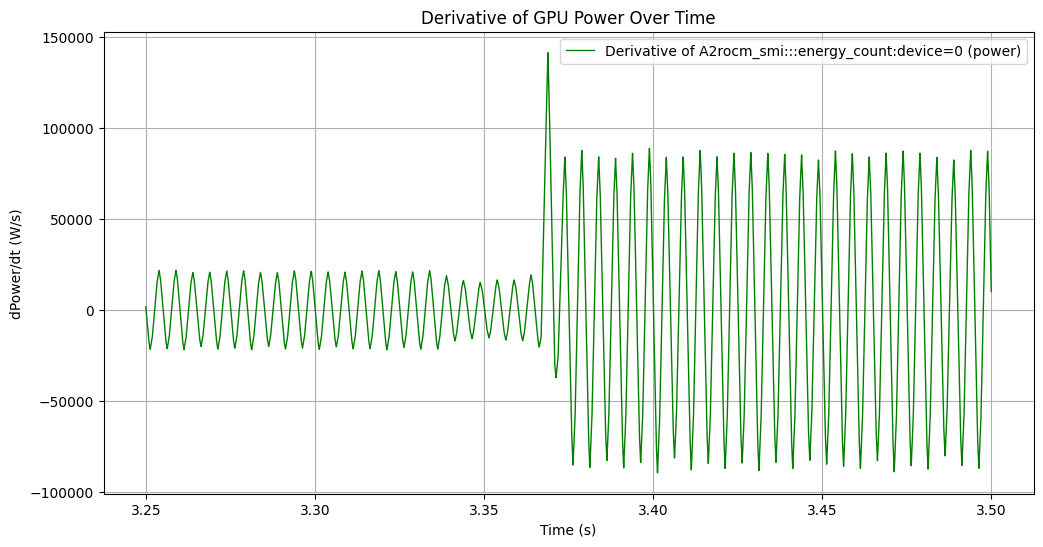

In [18]:
# Show the derivative of the rocm GPU power
def plot_derivative_of_power(power_functions, t_min=0, t_max=15):
    plt.figure(figsize=(12, 6))
    x = np.linspace(t_min, t_max, num=int((t_max - t_min) * 100000))
    ref_power = power_functions.get('A2rocm_smi:::energy_count:device=0 (power)', None)
    # plt.plot(x, ref_power(x), label='A2rocm_smi:::energy_count:device=0 (power)', color='blue', lw=1)
    ref_power_derivative = numerical_derivative(ref_power)
    plt.plot(x, ref_power_derivative(x), label='Derivative of A2rocm_smi:::energy_count:device=0 (power)', color='green', lw=1)
    plt.xlabel('Time (s)')
    plt.ylabel('dPower/dt (W/s)')
    plt.title('Derivative of GPU Power Over Time')
    plt.legend()
    plt.grid()
    plt.show()
plot_derivative_of_power(gpu_power_functions[TRACE], t_min=3.25, t_max=3.5)


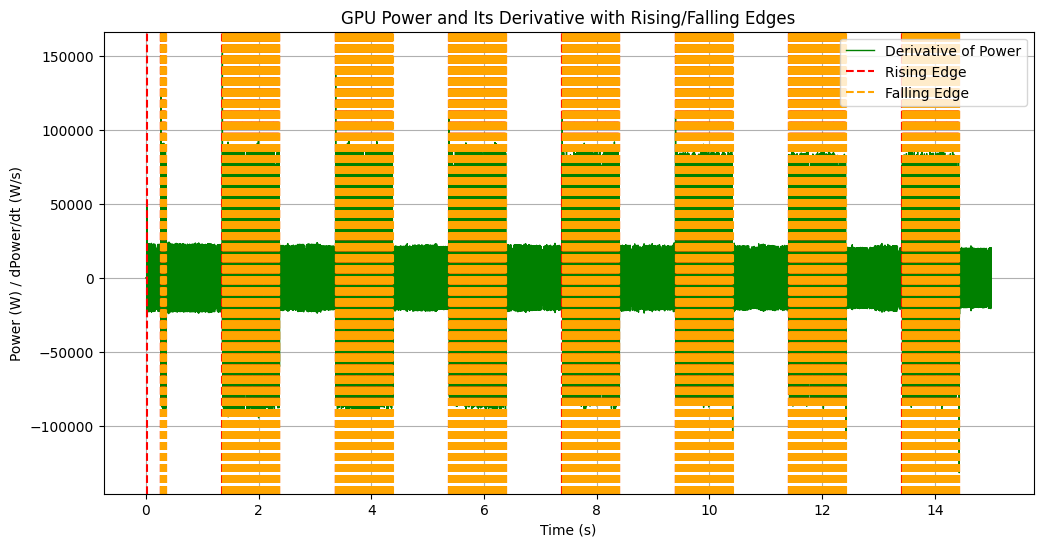

In [19]:

# Plot the energy between rising edges > 1 and falling edges < 1 of the compute activity
def calculate_energy_between_edges(power_functions, t_min=0, t_max=15):
    plt.figure(figsize=(12, 6))
    x = np.linspace(t_min, t_max, num=int((t_max - t_min) * 10000))
    ref_power = power_functions.get('A2rocm_smi:::energy_count:device=0 (power)', None)
    power_values = ref_power(x)
    # Derivative
    power_derivative = numerical_derivative(ref_power, h=0.001)
    power_derivative_values = power_derivative(x)
    
    # Identify a threshold to find rising and falling edges
    threshold = np.percentile(np.abs(power_derivative_values), 90) * 0.5
    # Find rising and falling edges. These will NOT be instantaneous, so look for crossings
    
    rising = np.where((power_derivative_values[:-1] < threshold) & (power_derivative_values[1:] >= threshold))[0] + 1
    falling = np.where((power_derivative_values[:-1] > -threshold) & (power_derivative_values[1:] <= -threshold))[0] + 1
    
    # plt.plot(x, power_values, label='A2rocm_smi:::energy_count:device=0 (power)', color='blue', lw=1)
    plt.plot(x, power_derivative_values, label='Derivative of Power', color='green', lw=1)
    for r in rising:
        plt.axvline(x=x[r], color='red', linestyle='--', label='Rising Edge' if r == rising[0] else "")
    for f in falling:
        plt.axvline(x=x[f], color='orange', linestyle='--', label='Falling Edge' if f == falling[0] else "")
    plt.xlabel('Time (s)')
    plt.ylabel('Power (W) / dPower/dt (W/s)')
    plt.title('GPU Power and Its Derivative with Rising/Falling Edges')
    plt.legend()
    plt.grid()
    plt.show()
calculate_energy_between_edges(gpu_power_functions[TRACE], t_min=0, t_max=15)
    

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt, savgol_filter
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt, savgol_filter
from sklearn.cluster import KMeans

def calculate_rising_and_falling_events(power_functions, t_min=0, t_max=15, vt_min=0, vt_max=15,
                              key='A2rocm_smi:::energy_count:device=0 (power)',
                              fs=10_000,
                              median_win=21,
                              sg_win=11, sg_poly=2,
                              alpha_up=0.35, beta_dn=0.65,
                              band_frac_low=0.10,   # ±10% for idle band width (relative)
                              band_frac_high=0.08,  # ±8%  for active band width (relative)
                              band_min_watts=12.0,  # absolute minimum band half-width in watts
                              hold_time=0.010,
                              min_gap=0.020,
                              debug_second_pass=True, plot: bool=True, summary: bool=True) -> List[Dict[str, Any]]:
    """
    Plot power vs. time, detect phase transitions (idle<->active), and measure
    transition durations using a robust, derivative-free method.

    ---------------------------
    What this function assumes:
    ---------------------------
    - The signal is a "spiky sawtooth" around two quasi-stable plateaus:
        * a lower 'idle' level
        * a higher 'active' level
      Short spikes/outliers are common and should *not* define the plateaus.
    - Transitions between plateaus are not instantaneous; we want the time from:
        t_start : when we *commit* to leaving the old plateau
        t_end   : when we *settle* inside a band around the new plateau and remain
                  there for a minimum hold time.

    ----------------------------------
    High-level algorithm (step-by-step)
    ----------------------------------
    1) Resample the provided power function uniformly on [t_min, t_max] at
       nominal sampling rate `fs`. This creates arrays `x` (time) and `y` (power).

    2) Robust smoothing:
       - Median filter (window `median_win`) removes narrow spikes without
         smearing step edges too much.
       - Savitzky–Golay filter (window `sg_win`, poly `sg_poly`) smooths residual
         noise while preserving step/edge shape better than a simple moving average.

    3) Robust level estimation:
       - Percentile clip the smoothed series to [1st, 99th] to suppress extreme
         outliers that would bias clustering.
       - Run K-means with k=2 on the clipped series to separate samples into
         two clusters. For each cluster, use the *median* (not the mean) as the
         representative level. Sort them to get:
             mu_low  ~ idle level
             mu_high ~ active level

    4) Build settling bands around those levels:
       - Compute a robust spread using MAD (Median Absolute Deviation) and scale
         by 1.4826 ~ sigma for Gaussian. The settling band half-width is the max of:
             (relative fraction of the center level) vs (absolute minimum watts)
             vs (MAD-based width)
         This ensures the band is wide enough to cover the sawtooth ripple but
         not so wide that it swallows a whole transition.

    5) Hysteresis thresholds to avoid chatter:
       - Two thresholds between mu_low and mu_high:
            th_up = mu_low + alpha_up * (mu_high - mu_low)   (enter ACTIVE)
            th_dn = mu_low + beta_dn  * (mu_high - mu_low)   (enter IDLE)
         with beta_dn < alpha_up. This prevents rapid bouncing due to ripple.

    6) Build a binary state machine over time:
       - Start in state=0 (idle).
       - If state==0 and y >= th_up  -> state=1 (we are rising into active).
       - If state==1 and y <= th_dn  -> state=0 (we are falling into idle).
       This tracks when we *intend* to be in each phase, ignoring brief crossings.

    7) For each 0->1 (rise) or 1->0 (fall) edge in the state machine:
       - Define t_start at the first sample where the state flips.
       - Search forward for the earliest index where the signal stays inside the
         corresponding target band (high band for rise, low band for fall) for
         at least `hold_time`. That index defines t_end.
       - Record event type ('rise' or 'fall'), t_start, t_end, and duration.

    8) Optional "second pass" if no events were found:
       - As a safety valve, widen the bands slightly and reduce hold time,
         then retry the detection (helps when the bands ended up too tight).

    9) Plot:
       - Raw power, smoothed power, hysteresis thresholds, settling bands
         (shaded), vertical lines at t_start / t_end, and shaded spans showing
         transition durations.
       - Overlay HIP/MPI call markers if present in `traces[TRACE][1]`.

    -----------------
    Key parameters:
    -----------------
    - fs:         resampling rate (Hz) used to discretize time.
    - median_win: median filter window length (odd). Choose ~1–2 sawtooth periods.
    - sg_win:     Savitzky–Golay window length (odd). Keep small to preserve steps.
    - sg_poly:    Savitzky–Golay polynomial degree (2 is usually enough).
    - alpha_up, beta_dn: hysteresis fractions between the two centroid levels.
    - band_frac_low/high: relative half-band width (as a fraction of level).
    - band_min_watts: absolute minimum half-band width in watts.
    - hold_time:  required time the signal must remain in-band to consider it
                  "settled" at the new level (prevents false positives).
    - min_gap:    skip ahead by this time after closing an event to avoid counting
                  overlapping/duplicate transitions.
    - debug_second_pass: whether to widen bands & reduce hold time if nothing was found.

    Returns:
        events: list of dicts with fields:
            - type: 'rise' or 'fall'
            - t_start: transition start time (s)
            - t_end:   transition end time (s)
            - duration: t_end - t_start (s)
    """
    # --- 1) Uniform resampling over [t_min, t_max] ---
    x = np.linspace(t_min, t_max, num=max(2, int((t_max - t_min) * fs)))
    ref_power = power_functions.get(key, None)
    if ref_power is None:
        raise KeyError(f"Series '{key}' not found in power_functions")
    y = ref_power(x)

    # --- 2) Robust smoothing: Median -> Savitzky–Golay ---
    # Both median and Savitzky–Golay require odd window sizes. If an even value
    # is provided, bump it by 1 so the filters run as expected.
    if median_win % 2 == 0: median_win += 1
    if sg_win % 2 == 0: sg_win += 1
    # Median filter: strongly suppresses narrow spikes without blurring edges much.
    y_med = medfilt(y, kernel_size=median_win)
    # Savitzky–Golay: smooth residual noise, preserve step edges better than MA.
    y_smooth = savgol_filter(y_med, sg_win, sg_poly, mode='interp')
    # y_smooth = y_med

    # --- 3) Percentile clipping to remove extreme outliers before clustering ---
    # Outliers can drag K-Means centroids and corrupt level estimation. Clip to
    # the 1st and 99th percentiles to limit their influence.
    p1, p99 = np.percentile(y_smooth, [1, 99])
    y_clip = np.clip(y_smooth, p1, p99)

    # --- 4) Two-cluster K-Means; use per-cluster medians as level estimates ---
    # We cluster the clipped smoothed signal into two groups (idle/active).
    # Instead of the centroid mean, we take the per-cluster *median* which is
    # more robust under asymmetrical distributions (sawtooth).
    km = KMeans(n_clusters=2, n_init='auto', random_state=0)
    km.fit(y_clip.reshape(-1, 1))
    labels = km.labels_
    c0 = np.median(y_clip[labels == 0])
    c1 = np.median(y_clip[labels == 1])
    mu_low, mu_high = (c0, c1) if c0 < c1 else (c1, c0)
    print(f"Estimated levels: mu_low={mu_low:.2f} W, mu_high={mu_high:.2f} W")

    # --- 5) Build robust settling bands using MAD + relative and absolute floors ---
    # The band half-width is the maximum of:
    #   (a) relative fraction of the level (band_frac_* * center),
    #   (b) absolute floor in watts (band_min_watts),
    #   (c) 1.4826 * MAD  (robust spread similar to sigma for Gaussian).
    def robust_band(vals, center, frac, min_w):
        mad = np.median(np.abs(vals - np.median(vals))) + 1e-9
        half = max(frac * center, min_w, 1.4826 * mad)
        return (center - half, center + half)

    # Split samples into "likely low" and "likely high" using the midpoint as a cut.
    low_vals  = y_clip[y_clip <= (mu_low + 0.5*(mu_high-mu_low))]
    high_vals = y_clip[y_clip >= (mu_low + 0.5*(mu_high-mu_low))]
    band_low  = robust_band(low_vals,  mu_low,  band_frac_low,  band_min_watts)
    band_high = robust_band(high_vals, mu_high, band_frac_high, band_min_watts)

    # --- 6) Hysteresis thresholds between the two levels ---
    # th_up defines when we "enter active" coming from idle.
    # th_dn defines when we "enter idle" coming from active.
    # Typically choose beta_dn < alpha_up to create hysteresis.
    th_up = mu_low + alpha_up*(mu_high - mu_low)
    th_dn = mu_low + beta_dn*(mu_high - mu_low)

    # --- 7) Binary state machine (0=idle, 1=active) driven by hysteresis ---
    # This avoids chattering caused by the sawtooth around the thresholds.
    state = np.zeros_like(y_smooth, dtype=int)
    cur = 0
    for i, val in enumerate(y_smooth):
        if cur == 0 and val >= th_up: cur = 1
        elif cur == 1 and val <= th_dn: cur = 0
        state[i] = cur

    # Convert time-based parameters to samples using the median timestep `dt`.
    dt = float(np.median(np.diff(x)))
    hold_n = max(1, int(round(hold_time / dt)))   # samples required to be continuously in-band
    min_gap_n = max(1, int(round(min_gap / dt)))  # skip-ahead after closing an event

    # Helper: starting from `idx_start`, find the earliest index where the next
    # `hold_n` samples all lie inside [lo, hi]. Return the last index of that
    # hold window (j-1), or None if such a window doesn't exist until the end.
    def settles(idx_start, lo, hi):
        i = idx_start
        while i < len(y_smooth):
            j = i + hold_n
            if j > len(y_smooth): return None
            seg = y_smooth[i:j]
            if np.all((seg >= lo) & (seg <= hi)):
                return j-1
            i += 1
        return None

    # Scan the state array and extract all rise (0->1) and fall (1->0) events.
    # For each event, compute t_start at the state flip and t_end at the first
    # index where the signal remains in-band for `hold_n` samples.
    def extract_events():
        events = []
        i = 1
        while i < len(state):
            # Rising edge: idle -> active
            if state[i-1]==0 and state[i]==1:
                t_start = x[i]
                j = settles(i, *band_high)
                if j is not None:
                    t_end = x[j]
                    events.append(dict(type='rise', t_start=t_start, t_end=t_end,
                                       duration=t_end - t_start))
                    i = j + min_gap_n
                    continue
            # Falling edge: active -> idle
            if state[i-1]==1 and state[i]==0:
                t_start = x[i]
                j = settles(i, *band_low)
                if j is not None:
                    t_end = x[j]
                    events.append(dict(type='fall', t_start=t_start, t_end=t_end,
                                       duration=t_end - t_start))
                    i = j + min_gap_n
                    continue
            i += 1
        return events
    print("Extracting events...")
    events = extract_events()
    print(f"Found {len(events)} events in first pass.")

    # --- 8) Optional second pass if nothing was found ---
    # If the bands were too tight and prevented settling, widen them slightly
    # and reduce the hold time; then try extraction again.
    if debug_second_pass and len(events) == 0:
        print("No events found; running second pass with relaxed bands and hold time...")
        band_frac_low2  = max(band_frac_low, 0.15)
        band_frac_high2 = max(band_frac_high, 0.12)
        band_low  = robust_band(low_vals,  mu_low,  band_frac_low2,  band_min_watts)
        band_high = robust_band(high_vals, mu_high, band_frac_high2, band_min_watts)
        hold_n = max(1, int(round(max(0.004, hold_time*0.5) / dt)))
        events = extract_events()
        print(f"Found {len(events)} events in second pass.")

    # ------------- Verification prints (safe, non-intrusive) -------------
    print(
        f"[levels] mu_low={mu_low:.3f} W, mu_high={mu_high:.3f} W | "
        f"th_up={th_up:.3f} W, th_dn={th_dn:.3f} W"
    )
    print(
        f"[bands]  low=({band_low[0]:.3f},{band_low[1]:.3f}) W, "
        f"high=({band_high[0]:.3f},{band_high[1]:.3f}) W | "
        f"dt={dt*1e3:.3f} ms, hold_n={hold_n}, min_gap_n={min_gap_n}"
    )
    if plot:
        # --- 9) Plot: raw + smoothed + thresholds + bands + events ---
        plt.figure(figsize=(12, 6))
        plt.plot(x, y, lw=0.7, alpha=0.35, label='Power (raw)')
        plt.plot(x, y_smooth, lw=1.2, label='Power (smoothed)')
        # Hysteresis thresholds:
        plt.axhline(th_up, color='tab:green', ls='--', lw=1, label='th_up (enter active)')
        plt.axhline(th_dn, color='tab:orange', ls='--', lw=1, label='th_dn (enter idle)')
        # Settling bands:
        plt.fill_between(x, band_high[0], band_high[1], color='tab:green', alpha=0.10, label='active band (settle)')
        plt.fill_between(x, band_low[0],  band_low[1],  color='tab:orange', alpha=0.10, label='idle band (settle)')

        # Event markers and shaded transition durations:
        for k, ev in enumerate(events):
            col = 'red' if ev['type']=='rise' else 'purple'
            plt.axvline(ev['t_start'], color=col, ls='--', lw=1,
                        label=('start rise' if ev['type']=='rise' and k==0 else
                            'start fall' if ev['type']=='fall' and k==0 else ""))
            plt.axvline(ev['t_end'], color=col, ls='-', lw=1,
                        label=('end rise' if ev['type']=='rise' and k==0 else
                            'end fall' if ev['type']=='fall' and k==0 else ""))
            plt.axvspan(ev['t_start'], ev['t_end'], color=col, alpha=0.12)

        plt.title('GPU Power: transitions and durations (robust levels + hysteresis + hold)')
        plt.xlabel('Time (s)')
        plt.ylabel('Power (W)')
        plt.grid(alpha=0.3)
        plt.tight_layout()

        # --- 10) Overlay MPI/HIP call starts (if present) --------------------
        # We overlay vertical dotted lines at the *start time* of selected runtime calls.
        # This helps eyeball-corroborate whether state changes line up with kernel launches, etc.
        # Notes:
        # - The code expects `traces[TRACE][1]` to be a DataFrame with columns:
        #     ['Name', 'Start Time', ...]
        # - Only calls listed in `calls_to_mpi` or `calls_to_hip` are plotted.
        # - We further restrict to the visible interval [t_min, t_max].
        # - If your DataFrame uses different column names, adapt the filters accordingly.
        # - If there are many events, the legend might get dense; feel free to remove labels.
        # calls_to_mpi = ['MPI_Init', 'MPI_Finalize', 'MPI_Send', 'MPI_Recv', 'MPI_Isend', 'MPI_Irecv', 'MPI_Wait']
        calls_to_mpi = []
        calls_to_hip = ['hipLaunchKernel']
        call_graph_df = traces[TRACE][1]
        call_graph_df = call_graph_df[(call_graph_df['Start Time'] >= t_min) & (call_graph_df['Start Time'] <= t_max)]
        call_graph_df = call_graph_df[call_graph_df['Name'].isin(calls_to_mpi + calls_to_hip)]
        print(f"Overlaying {len(call_graph_df)} MPI/HIP calls on the plot.")
        last_func = -1
        for index, row in call_graph_df.iterrows():
            if last_func >= 0 and row['Start Time'] - last_func < 0.050:
                # Skip this launch to avoid overplotting
                continue
            # Shade the region from the start to end time
            x = [row['Start Time'], row['End Time']]
            y = [0, max(y_smooth)*1.1]
            if row['Name'] in calls_to_mpi:
                last_func = row['Start Time']
                plt.fill_between(x, 0, y[1], color='cyan', alpha=0.025,
                                label=row['Name'] if index == call_graph_df.index[0] else "")
            elif row['Name'] in calls_to_hip:
                last_func = row['Start Time']
                plt.fill_between(x, 0, y[1], color='cornflowerblue', alpha=0.025,
                                label=row['Name'] if index == call_graph_df.index[0] else "")

        # Final legend call (after overlay lines so labels are included if any)
        plt.legend(ncol=2)
        # Cut the plot to the visible range
        plt.xlim(vt_min, vt_max)
        plt.ylim(0, None)
        plt.show()
    if summary:
        # Console summary of detected transitions (start, end, duration in ms)
        for ev in events:
            print(f"{ev['type']:>4}  start={ev['t_start']:.6f}s  end={ev['t_end']:.6f}s  "
                f"duration={ev['duration']*1e3:.3f} ms")
        print('Average rising duration: {:.3f} ms'.format(
            sum(ev['duration']*1e3 for ev in events if ev['type'] == 'rise') /
            sum(1 for ev in events if ev['type'] == 'rise')))
        print('Average falling duration: {:.3f} ms'.format(
            sum(ev['duration']*1e3 for ev in events if ev['type'] == 'fall') /
            sum(1 for ev in events if ev['type'] == 'fall')))
    return events

In [21]:
def calculate_average_rising_and_falling_durations(events: List[Dict[str, Any]]) -> Tuple[float, float]:
    rising_durations = [ev['duration'] for ev in events if ev['type'] == 'rise']
    falling_durations = [ev['duration'] for ev in events if ev['type'] == 'fall']
    avg_rising = sum(rising_durations) / len(rising_durations) if rising_durations else 0.0
    avg_falling = sum(falling_durations) / len(falling_durations) if falling_durations else 0.0
    return avg_rising, avg_falling

events = calculate_rising_and_falling_events(gpu_power_functions[TRACE], alpha_up=0.1, beta_dn=0.7, vt_min=2, vt_max=13, hold_time=0.003, t_min=2, t_max=13, plot=False, summary=False)
avg_rising, avg_falling = calculate_average_rising_and_falling_durations(events)
print(f"Average Rising Duration: {avg_rising*1e3:.3f} ms")
print(f"Average Falling Duration: {avg_falling*1e3:.3f} ms")

Estimated levels: mu_low=92.28 W, mu_high=363.73 W
Extracting events...
Found 11 events in first pass.
[levels] mu_low=92.276 W, mu_high=363.727 W | th_up=119.421 W, th_dn=282.292 W
[bands]  low=(74.153,110.398) W, high=(288.902,438.553) W | dt=0.100 ms, hold_n=30, min_gap_n=200
Average Rising Duration: 7.500 ms
Average Falling Duration: 8.000 ms


In [24]:
def calculate_average_rising_and_falling_durations(events: List[Dict[str, Any]]) -> Tuple[float, float]:
    rising_durations = [ev['duration'] for ev in events if ev['type'] == 'rise']
    falling_durations = [ev['duration'] for ev in events if ev['type'] == 'fall']
    avg_rising = sum(rising_durations) / len(rising_durations) if rising_durations else 0.0
    avg_falling = sum(falling_durations) / len(falling_durations) if falling_durations else 0.0
    return avg_rising, avg_falling

events = calculate_rising_and_falling_events(gpu_power_functions[TRACE], alpha_up=0.1, beta_dn=0.7, vt_min=2, vt_max=13, hold_time=0.003, t_min=2, t_max=13, plot=False, summary=False)
avg_rising, avg_falling = calculate_average_rising_and_falling_durations(events)
print(f"Average Rising Duration: {avg_rising*1e3:.3f} ms")
print(f"Average Falling Duration: {avg_falling*1e3:.3f} ms")

Estimated levels: mu_low=92.28 W, mu_high=363.73 W
Extracting events...
Found 11 events in first pass.
[levels] mu_low=92.276 W, mu_high=363.727 W | th_up=119.421 W, th_dn=282.292 W
[bands]  low=(74.153,110.398) W, high=(288.902,438.553) W | dt=0.100 ms, hold_n=30, min_gap_n=200
Average Rising Duration: 7.500 ms
Average Falling Duration: 8.000 ms


Estimated levels: mu_low=92.28 W, mu_high=363.73 W
Extracting events...
Found 11 events in first pass.
[levels] mu_low=92.276 W, mu_high=363.727 W | th_up=119.421 W, th_dn=282.292 W
[bands]  low=(74.153,110.398) W, high=(288.902,438.553) W | dt=0.100 ms, hold_n=30, min_gap_n=200
Overlaying 5550 MPI/HIP calls on the plot.


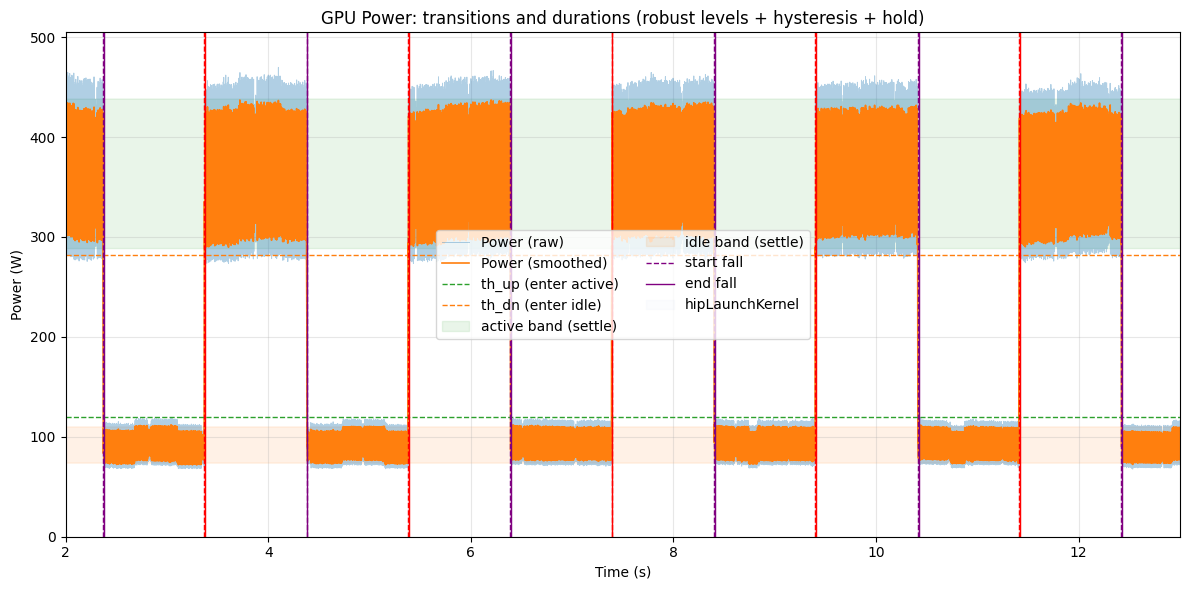

fall  start=2.367503s  end=2.374703s  duration=7.200 ms
rise  start=3.368312s  end=3.375813s  duration=7.500 ms
fall  start=4.377522s  end=4.385022s  duration=7.500 ms
rise  start=5.378531s  end=5.386031s  duration=7.500 ms
fall  start=6.388440s  end=6.398840s  duration=10.400 ms
rise  start=7.388549s  end=7.396049s  duration=7.500 ms
fall  start=8.398658s  end=8.408858s  duration=10.200 ms
rise  start=9.398667s  end=9.406167s  duration=7.500 ms
fall  start=10.410876s  end=10.419077s  duration=8.200 ms
rise  start=11.408886s  end=11.416386s  duration=7.500 ms
fall  start=12.420995s  end=12.425495s  duration=4.500 ms
Average rising duration: 7.500 ms
Average falling duration: 8.000 ms
Estimated levels: mu_low=92.28 W, mu_high=363.73 W
Extracting events...
Found 11 events in first pass.
[levels] mu_low=92.276 W, mu_high=363.727 W | th_up=119.421 W, th_dn=282.292 W
[bands]  low=(74.153,110.398) W, high=(288.902,438.553) W | dt=0.100 ms, hold_n=30, min_gap_n=200
Overlaying 5550 MPI/HIP cal

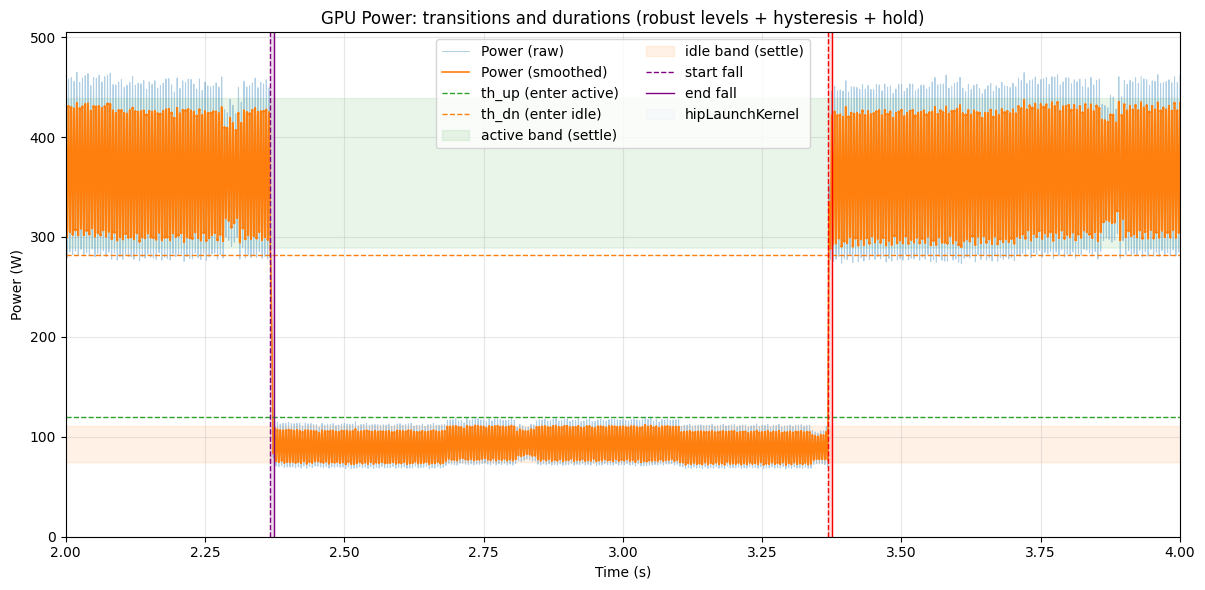

fall  start=2.367503s  end=2.374703s  duration=7.200 ms
rise  start=3.368312s  end=3.375813s  duration=7.500 ms
fall  start=4.377522s  end=4.385022s  duration=7.500 ms
rise  start=5.378531s  end=5.386031s  duration=7.500 ms
fall  start=6.388440s  end=6.398840s  duration=10.400 ms
rise  start=7.388549s  end=7.396049s  duration=7.500 ms
fall  start=8.398658s  end=8.408858s  duration=10.200 ms
rise  start=9.398667s  end=9.406167s  duration=7.500 ms
fall  start=10.410876s  end=10.419077s  duration=8.200 ms
rise  start=11.408886s  end=11.416386s  duration=7.500 ms
fall  start=12.420995s  end=12.425495s  duration=4.500 ms
Average rising duration: 7.500 ms
Average falling duration: 8.000 ms
Estimated levels: mu_low=92.28 W, mu_high=363.73 W
Extracting events...
Found 11 events in first pass.
[levels] mu_low=92.276 W, mu_high=363.727 W | th_up=119.421 W, th_dn=282.292 W
[bands]  low=(74.153,110.398) W, high=(288.902,438.553) W | dt=0.100 ms, hold_n=30, min_gap_n=200
Overlaying 5550 MPI/HIP cal

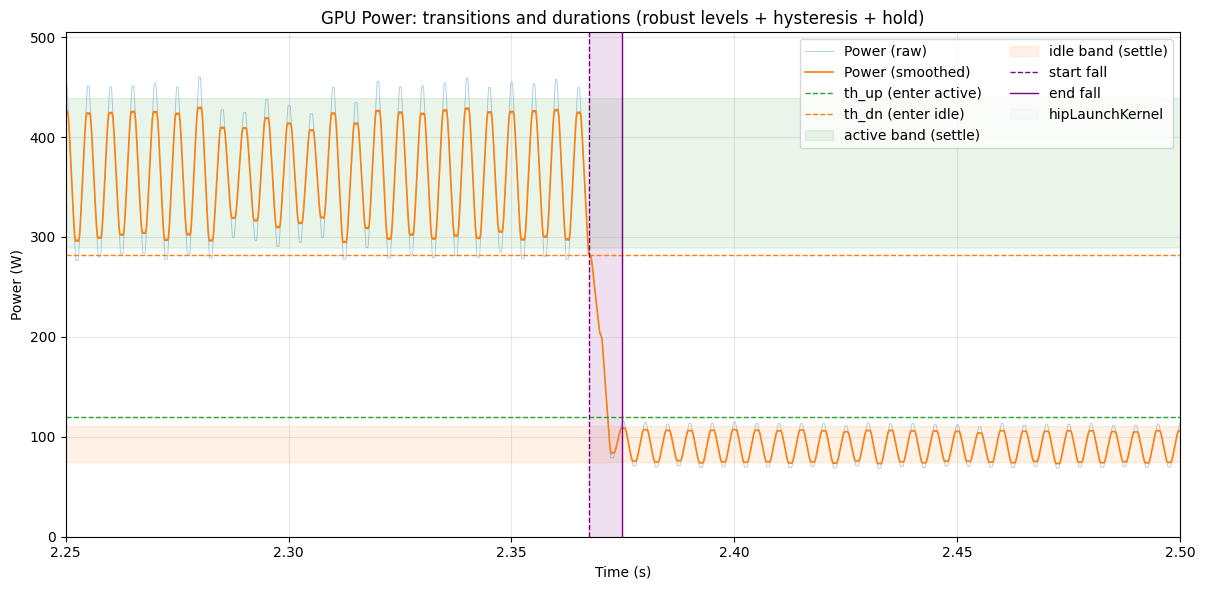

fall  start=2.367503s  end=2.374703s  duration=7.200 ms
rise  start=3.368312s  end=3.375813s  duration=7.500 ms
fall  start=4.377522s  end=4.385022s  duration=7.500 ms
rise  start=5.378531s  end=5.386031s  duration=7.500 ms
fall  start=6.388440s  end=6.398840s  duration=10.400 ms
rise  start=7.388549s  end=7.396049s  duration=7.500 ms
fall  start=8.398658s  end=8.408858s  duration=10.200 ms
rise  start=9.398667s  end=9.406167s  duration=7.500 ms
fall  start=10.410876s  end=10.419077s  duration=8.200 ms
rise  start=11.408886s  end=11.416386s  duration=7.500 ms
fall  start=12.420995s  end=12.425495s  duration=4.500 ms
Average rising duration: 7.500 ms
Average falling duration: 8.000 ms
Estimated levels: mu_low=92.28 W, mu_high=363.73 W
Extracting events...
Found 11 events in first pass.
[levels] mu_low=92.276 W, mu_high=363.727 W | th_up=119.421 W, th_dn=282.292 W
[bands]  low=(74.153,110.398) W, high=(288.902,438.553) W | dt=0.100 ms, hold_n=30, min_gap_n=200
Overlaying 5550 MPI/HIP cal

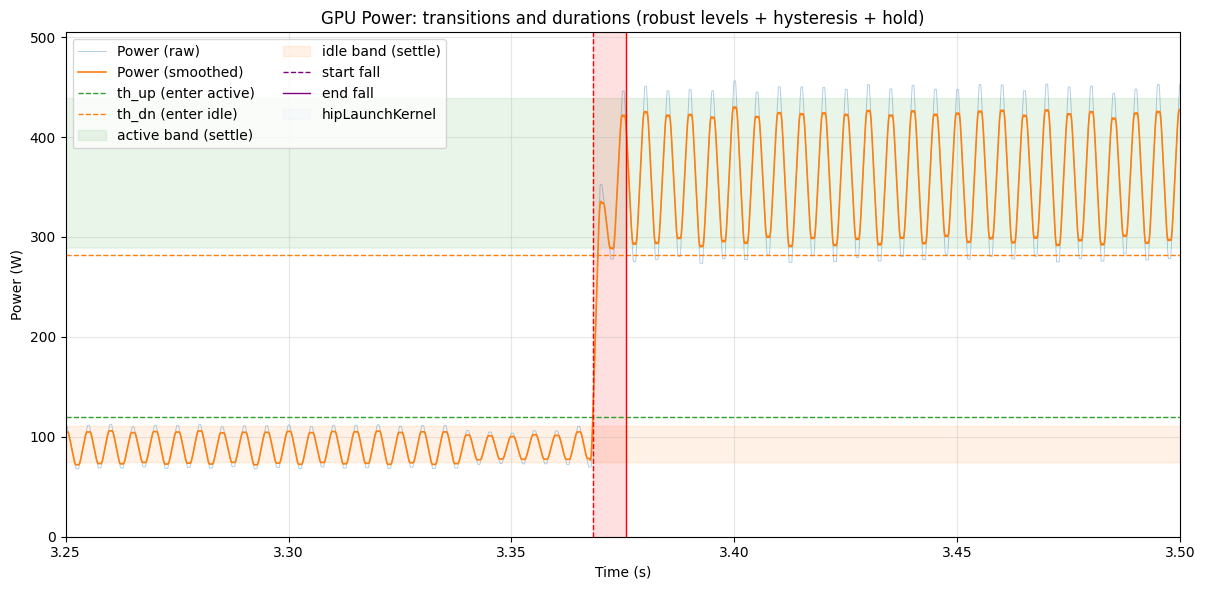

fall  start=2.367503s  end=2.374703s  duration=7.200 ms
rise  start=3.368312s  end=3.375813s  duration=7.500 ms
fall  start=4.377522s  end=4.385022s  duration=7.500 ms
rise  start=5.378531s  end=5.386031s  duration=7.500 ms
fall  start=6.388440s  end=6.398840s  duration=10.400 ms
rise  start=7.388549s  end=7.396049s  duration=7.500 ms
fall  start=8.398658s  end=8.408858s  duration=10.200 ms
rise  start=9.398667s  end=9.406167s  duration=7.500 ms
fall  start=10.410876s  end=10.419077s  duration=8.200 ms
rise  start=11.408886s  end=11.416386s  duration=7.500 ms
fall  start=12.420995s  end=12.425495s  duration=4.500 ms
Average rising duration: 7.500 ms
Average falling duration: 8.000 ms


[{'type': 'fall',
  't_start': 2.367503340939463,
  't_end': 2.3747034063946035,
  'duration': 0.007200065455140514},
 {'type': 'rise',
  't_start': 3.3683124392039927,
  't_end': 3.375812507386431,
  'duration': 0.007500068182438202},
 {'type': 'fall',
  't_start': 4.377521613832853,
  't_end': 4.3850216820152905,
  'duration': 0.007500068182437758},
 {'type': 'rise',
  't_start': 5.3785307139155805,
  't_end': 5.386030782098019,
  'duration': 0.007500068182438646},
 {'type': 'fall',
  't_start': 6.388439894908136,
  't_end': 6.39883998945445,
  'duration': 0.010400094546313632},
 {'type': 'rise',
  't_start': 7.388548986808971,
  't_end': 7.396049054991409,
  'duration': 0.007500068182438646},
 {'type': 'fall',
  't_start': 8.398658169619724,
  't_end': 8.40885826234784,
  'duration': 0.010200092728116061},
 {'type': 'rise',
  't_start': 9.398667260611461,
  't_end': 9.406167328793899,
  'duration': 0.007500068182437758},
 {'type': 'fall',
  't_start': 10.410876462513295,
  't_end': 

In [25]:
# Example usage:
calculate_rising_and_falling_events(gpu_power_functions[TRACE], alpha_up=0.1, beta_dn=0.7, vt_min=2, vt_max=13, hold_time=0.003, t_min=2, t_max=13)
calculate_rising_and_falling_events(gpu_power_functions[TRACE], alpha_up=0.1, beta_dn=0.7, vt_min=2, vt_max=4, hold_time=0.003, t_min=2, t_max=13)
calculate_rising_and_falling_events(gpu_power_functions[TRACE], alpha_up=0.1, beta_dn=0.7, vt_min=2.25, vt_max=2.5, hold_time=0.003, t_min=2, t_max=13)
calculate_rising_and_falling_events(gpu_power_functions[TRACE], alpha_up=0.1, beta_dn=0.7, vt_min=3.25, vt_max=3.5, hold_time=0.003, t_min=2, t_max=13)

Estimated levels: mu_low=95.27 W, mu_high=369.10 W
Extracting events...
Found 16 events in first pass.
[levels] mu_low=95.272 W, mu_high=369.095 W | th_up=117.178 W, th_dn=347.190 W
[bands]  low=(83.272,107.272) W, high=(354.332,383.859) W | dt=0.100 ms, hold_n=30, min_gap_n=200
Overlaying 7870 MPI/HIP calls on the plot.


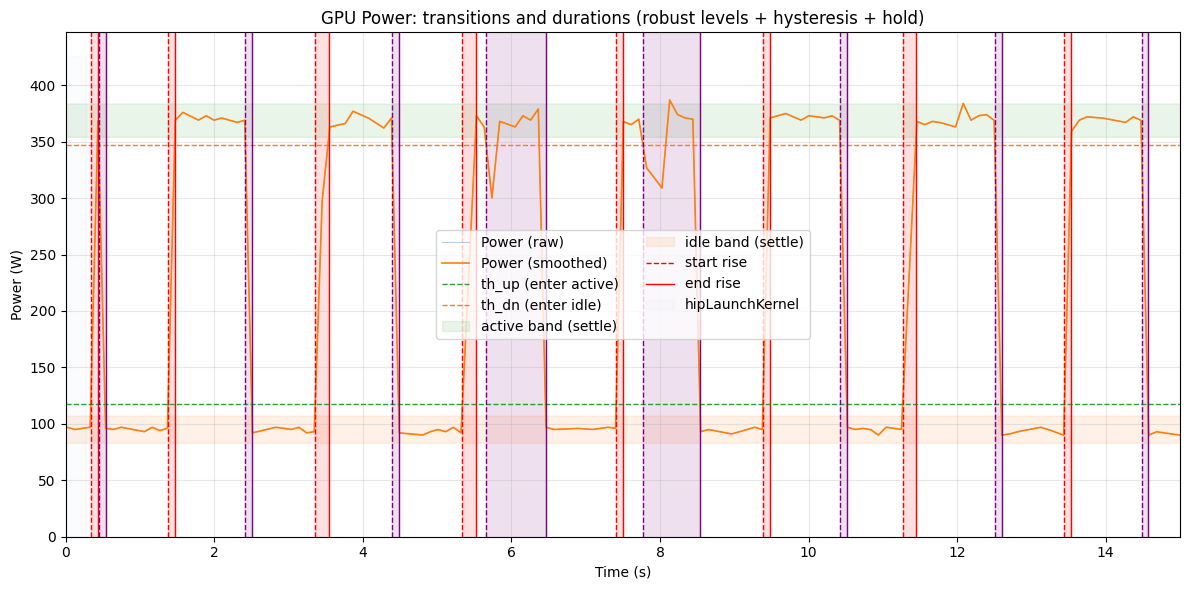

rise  start=0.337802s  end=0.431403s  duration=93.601 ms
fall  start=0.451403s  end=0.536704s  duration=85.301 ms
rise  start=1.378109s  end=1.471310s  duration=93.201 ms
fall  start=2.418816s  end=2.511817s  duration=93.001 ms
rise  start=3.358822s  end=3.543824s  duration=185.001 ms
fall  start=4.395229s  end=4.487530s  duration=92.301 ms
rise  start=5.340736s  end=5.519137s  duration=178.401 ms
fall  start=5.660138s  end=6.465443s  duration=805.305 ms
rise  start=7.410849s  end=7.504350s  duration=93.501 ms
fall  start=7.769952s  end=8.544257s  duration=774.305 ms
rise  start=9.386363s  end=9.478463s  duration=92.101 ms
fall  start=10.426270s  end=10.520970s  duration=94.701 ms
rise  start=11.266975s  end=11.450576s  duration=183.601 ms
fall  start=12.506383s  end=12.598784s  duration=92.401 ms
rise  start=13.444790s  end=13.539390s  duration=94.601 ms
fall  start=14.482097s  end=14.574497s  duration=92.401 ms
Average rising duration: 126.751 ms
Average falling duration: 266.214 ms


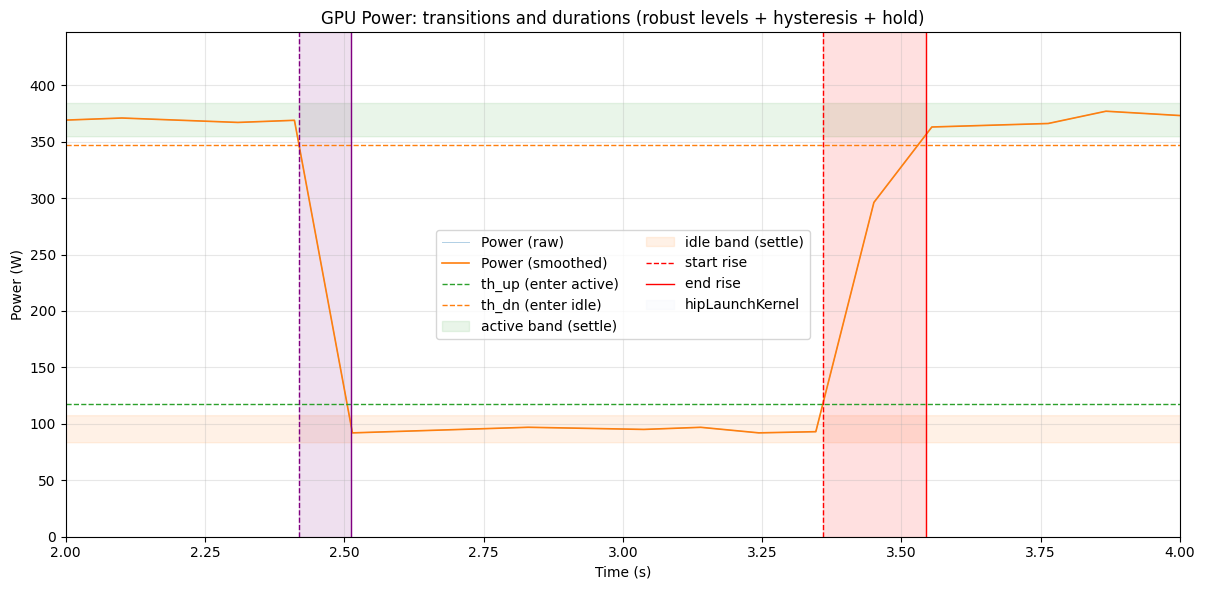

rise  start=0.337802s  end=0.431403s  duration=93.601 ms
fall  start=0.451403s  end=0.536704s  duration=85.301 ms
rise  start=1.378109s  end=1.471310s  duration=93.201 ms
fall  start=2.418816s  end=2.511817s  duration=93.001 ms
rise  start=3.358822s  end=3.543824s  duration=185.001 ms
fall  start=4.395229s  end=4.487530s  duration=92.301 ms
rise  start=5.340736s  end=5.519137s  duration=178.401 ms
fall  start=5.660138s  end=6.465443s  duration=805.305 ms
rise  start=7.410849s  end=7.504350s  duration=93.501 ms
fall  start=7.769952s  end=8.544257s  duration=774.305 ms
rise  start=9.386363s  end=9.478463s  duration=92.101 ms
fall  start=10.426270s  end=10.520970s  duration=94.701 ms
rise  start=11.266975s  end=11.450576s  duration=183.601 ms
fall  start=12.506383s  end=12.598784s  duration=92.401 ms
rise  start=13.444790s  end=13.539390s  duration=94.601 ms
fall  start=14.482097s  end=14.574497s  duration=92.401 ms
Average rising duration: 126.751 ms
Average falling duration: 266.214 ms


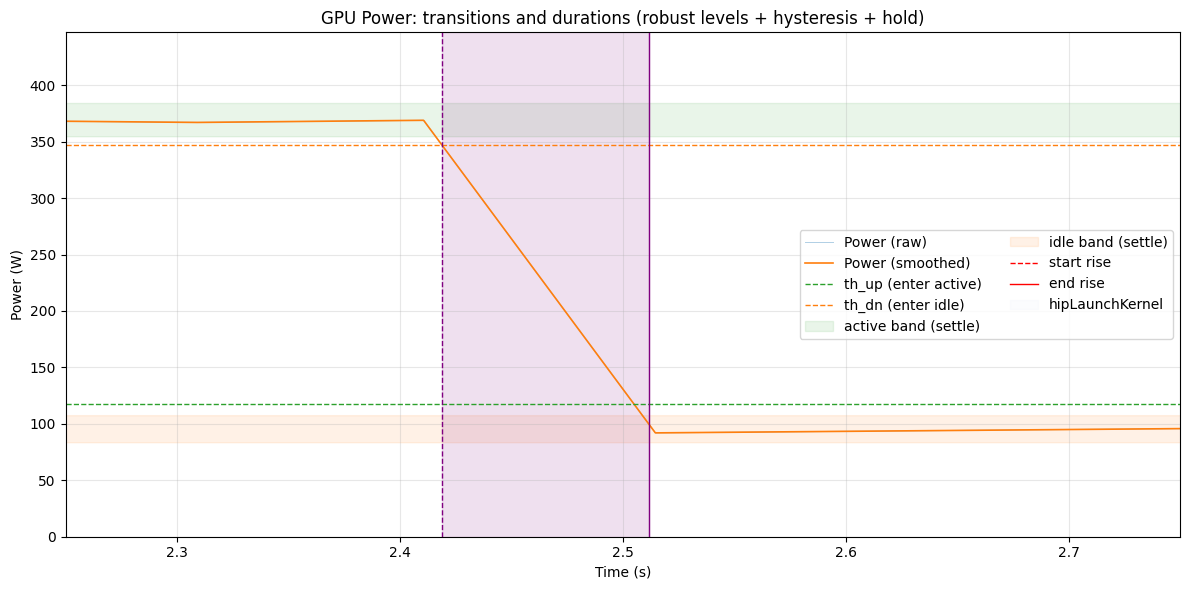

rise  start=0.337802s  end=0.431403s  duration=93.601 ms
fall  start=0.451403s  end=0.536704s  duration=85.301 ms
rise  start=1.378109s  end=1.471310s  duration=93.201 ms
fall  start=2.418816s  end=2.511817s  duration=93.001 ms
rise  start=3.358822s  end=3.543824s  duration=185.001 ms
fall  start=4.395229s  end=4.487530s  duration=92.301 ms
rise  start=5.340736s  end=5.519137s  duration=178.401 ms
fall  start=5.660138s  end=6.465443s  duration=805.305 ms
rise  start=7.410849s  end=7.504350s  duration=93.501 ms
fall  start=7.769952s  end=8.544257s  duration=774.305 ms
rise  start=9.386363s  end=9.478463s  duration=92.101 ms
fall  start=10.426270s  end=10.520970s  duration=94.701 ms
rise  start=11.266975s  end=11.450576s  duration=183.601 ms
fall  start=12.506383s  end=12.598784s  duration=92.401 ms
rise  start=13.444790s  end=13.539390s  duration=94.601 ms
fall  start=14.482097s  end=14.574497s  duration=92.401 ms
Average rising duration: 126.751 ms
Average falling duration: 266.214 ms


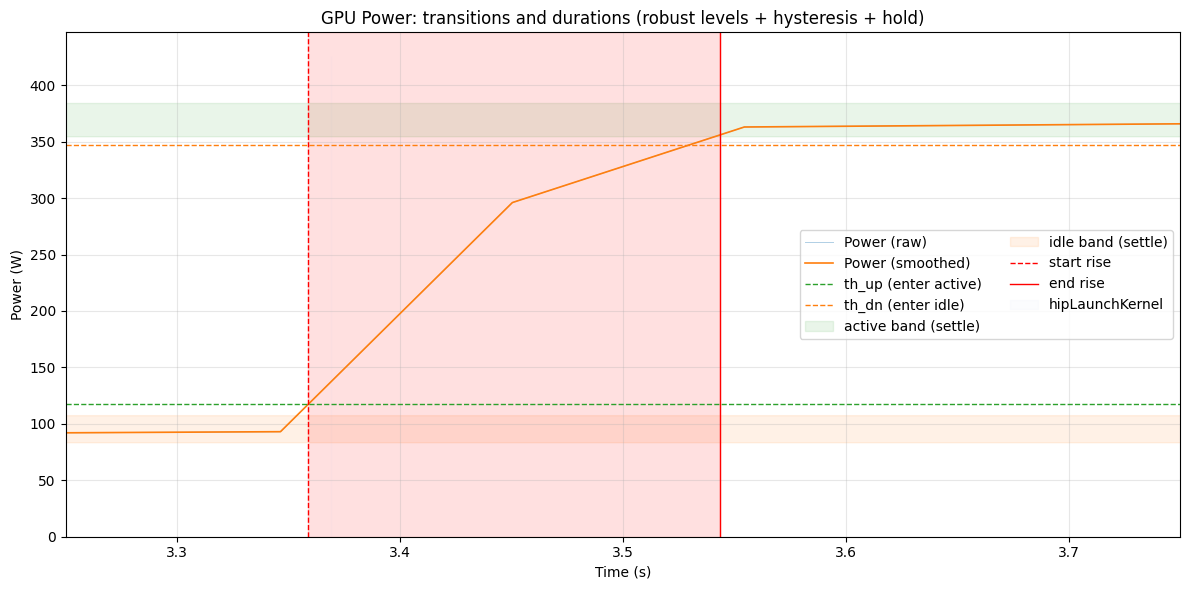

rise  start=0.337802s  end=0.431403s  duration=93.601 ms
fall  start=0.451403s  end=0.536704s  duration=85.301 ms
rise  start=1.378109s  end=1.471310s  duration=93.201 ms
fall  start=2.418816s  end=2.511817s  duration=93.001 ms
rise  start=3.358822s  end=3.543824s  duration=185.001 ms
fall  start=4.395229s  end=4.487530s  duration=92.301 ms
rise  start=5.340736s  end=5.519137s  duration=178.401 ms
fall  start=5.660138s  end=6.465443s  duration=805.305 ms
rise  start=7.410849s  end=7.504350s  duration=93.501 ms
fall  start=7.769952s  end=8.544257s  duration=774.305 ms
rise  start=9.386363s  end=9.478463s  duration=92.101 ms
fall  start=10.426270s  end=10.520970s  duration=94.701 ms
rise  start=11.266975s  end=11.450576s  duration=183.601 ms
fall  start=12.506383s  end=12.598784s  duration=92.401 ms
rise  start=13.444790s  end=13.539390s  duration=94.601 ms
fall  start=14.482097s  end=14.574497s  duration=92.401 ms
Average rising duration: 126.751 ms
Average falling duration: 266.214 ms


[{'type': 'rise',
  't_start': 0.33780225201501346,
  't_end': 0.4314028760191735,
  'duration': 0.09360062400416003},
 {'type': 'fall',
  't_start': 0.4514030093533957,
  't_end': 0.5367035780238535,
  'duration': 0.08530056867045777},
 {'type': 'rise',
  't_start': 1.3781091873945828,
  't_end': 1.4713098087320582,
  'duration': 0.09320062133747542},
 {'type': 'fall',
  't_start': 2.4188161254408365,
  't_end': 2.51181674544497,
  'duration': 0.09300062000413334},
 {'type': 'rise',
  't_start': 3.358822392149281,
  't_end': 3.5438236254908366,
  'duration': 0.1850012333415556},
 {'type': 'fall',
  't_start': 4.395229301528677,
  't_end': 4.487529916866112,
  'duration': 0.09230061533743505},
 {'type': 'rise',
  't_start': 5.340735604904033,
  't_end': 5.519136794245295,
  'duration': 0.1784011893412618},
 {'type': 'fall',
  't_start': 5.6601377342515615,
  't_end': 6.46544310295402,
  'duration': 0.8053053687024585},
 {'type': 'rise',
  't_start': 7.410849405662705,
  't_end': 7.5043

In [ ]:
# Example usage:
calculate_rising_and_falling_events(gpu_power_functions[TRACE], vt_min=0, vt_max=15, key='A2coretemp:::craypm:accel0_power (power)', alpha_up=0.08, beta_dn=0.92, band_frac_low=0.05, band_frac_high=0.04, hold_time=0.003)
calculate_rising_and_falling_events(gpu_power_functions[TRACE], vt_min=2, vt_max=4, key='A2coretemp:::craypm:accel0_power (power)', alpha_up=0.08, beta_dn=0.92, band_frac_low=0.05, band_frac_high=0.04, hold_time=0.003)
calculate_rising_and_falling_events(gpu_power_functions[TRACE], vt_min=2.25, vt_max=2.75, key='A2coretemp:::craypm:accel0_power (power)', alpha_up=0.08, beta_dn=0.92, band_frac_low=0.05, band_frac_high=0.04, hold_time=0.003)
calculate_rising_and_falling_events(gpu_power_functions[TRACE], vt_min=3.25, vt_max=3.75, key='A2coretemp:::craypm:accel0_power (power)', alpha_up=0.08, beta_dn=0.92, band_frac_low=0.05, band_frac_high=0.04, hold_time=0.003)

Estimated levels: mu_low=514.47 W, mu_high=1786.83 W
Extracting events...
Found 13 events in first pass.
[levels] mu_low=514.471 W, mu_high=1786.833 W | th_up=578.089 W, th_dn=1659.597 W
[bands]  low=(488.747,540.194) W, high=(1715.360,1858.306) W | dt=0.100 ms, hold_n=10, min_gap_n=200
Overlaying 6660 MPI/HIP calls on the plot.


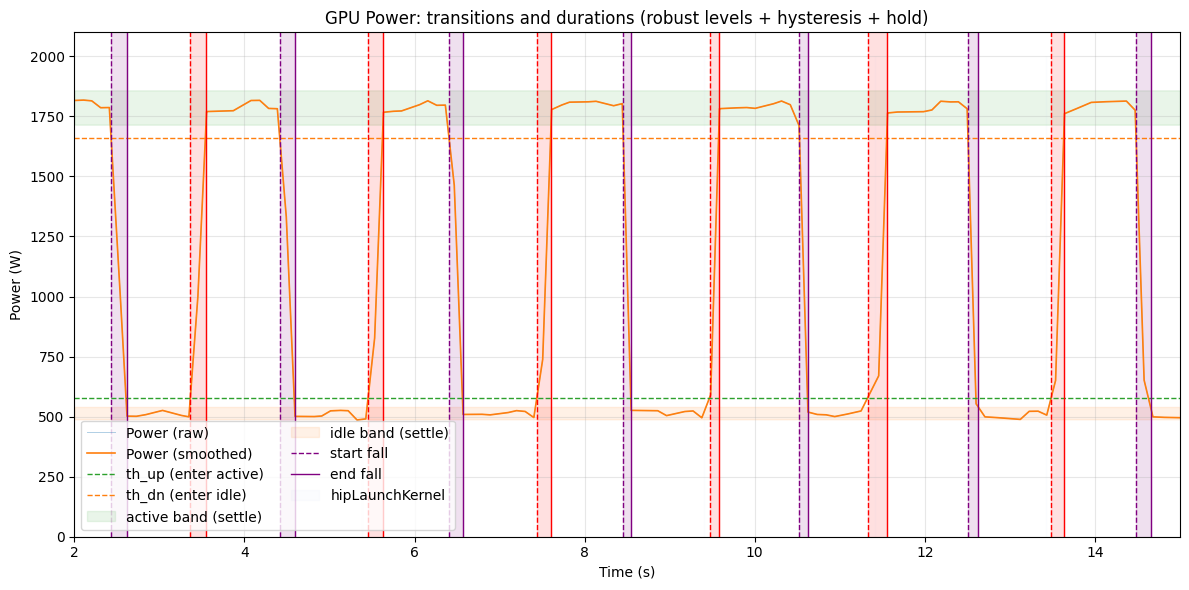

fall  start=2.431803s  end=2.613405s  duration=181.601 ms
rise  start=3.363310s  end=3.548112s  duration=184.801 ms
fall  start=4.415319s  end=4.590320s  duration=175.001 ms
rise  start=5.453827s  end=5.629328s  duration=175.501 ms
fall  start=6.405934s  end=6.567935s  duration=162.001 ms
rise  start=7.438442s  end=7.605443s  duration=167.001 ms
fall  start=8.454450s  end=8.546450s  duration=92.001 ms
rise  start=9.469757s  end=9.580858s  duration=111.101 ms
fall  start=10.526566s  end=10.625066s  duration=98.501 ms
rise  start=11.328572s  end=11.558374s  duration=229.802 ms
fall  start=12.508681s  end=12.629282s  duration=120.601 ms
rise  start=13.486688s  end=13.638790s  duration=152.101 ms
fall  start=14.484796s  end=14.655297s  duration=170.501 ms
Average rising duration: 170.051 ms
Average falling duration: 142.887 ms


[{'type': 'fall',
  't_start': 2.4318033215640122,
  't_end': 2.6134047184978346,
  'duration': 0.18160139693382238},
 {'type': 'rise',
  't_start': 3.363310487003746,
  't_end': 3.5481119085531425,
  'duration': 0.1848014215493965},
 {'type': 'fall',
  't_start': 4.415318579373688,
  't_end': 4.590319925537889,
  'duration': 0.17500134616420127},
 {'type': 'rise',
  't_start': 5.453826567896677,
  't_end': 5.6293279179070606,
  'duration': 0.17550135001038392},
 {'type': 'fall',
  't_start': 6.405933891799168,
  't_end': 6.5679351379626,
  'duration': 0.16200124616343192},
 {'type': 'rise',
  't_start': 7.438441834167955,
  't_end': 7.605443118793222,
  'duration': 0.16700128462526642},
 {'type': 'fall',
  't_start': 8.45444964961269,
  't_end': 8.546450357310441,
  'duration': 0.0920007076977516},
 {'type': 'rise',
  't_start': 9.469757459672767,
  't_end': 9.580858314294726,
  'duration': 0.1111008546219594},
 {'type': 'fall',
  't_start': 10.526565588966069,
  't_end': 10.625066346

In [ ]:

# Example usage:
calculate_rising_and_falling_events(gpu_power_functions[TRACE], t_min=2, vt_min=2, vt_max=15, key='A2coretemp:::craypm:power (power)', alpha_up=0.05, beta_dn=0.9, band_frac_low=0.05, band_frac_high=0.04, hold_time=0.003)